<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

# **LoanTap : Loan Eligibility Predictions & Repayment Terms**

<div style="font-family: 'Consolas'; color: #800000; font-size: 20px; line-height: 1.5;">

**Context:**

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">
    
**LoanTap** is an online platform committed to delivering customized loan products to millennials. The data science team at LoanTap is building an ***underwriting layer*** to determine the creditworthiness of MSMEs as well as individuals.

<div style="font-family: 'Consolas'; color: #800000; font-size: 17px; line-height: 1;">
    
LoanTap deploys formal credit to salaried individuals and businesses on four main financial instruments:

1.	Personal Loan
  
2.	EMI Free Loan
  
3.	Personal Overdraft
  
4.	Advance Salary Loan

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

>**Note:** Underwriting is the process where banks evaluate and assume the risk of an individual/business. It determines if a loan issuance is financially viable, ensuring risk is accurately priced

<div style="font-family: 'Consolas'; color: #800000; font-size: 20px; line-height: 1.3;">
    
**Problem Statement:**

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.3;">
    
>**Given a set of attributes for an Individual, determine if a credit line should be extended to them. If so, what should be the repayment terms ?**
>
>This is a binary classification problem where we have to classify the potential borrowers into 'eligible' or 'not eligible' for certain credit lines and devise a strategy for the repayment terms.


<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1;">

**Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1;">

**Data Loading & understanding the structure**

In [4]:
df = pd.read_csv("loan_tap.csv")
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1;">
    
**Exploratory Data Analysis**

In [5]:
df.shape

(396030, 27)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [7]:
# statistical summary
df.describe().loc[['mean', 'std', 'min', '50%', 'max']]

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1;">

**Findings:**
<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1;">
    
> Total Rows - 396030
> 
> Total Columns - 27
> 
> Datatypes : object, float
>
> Object ---> 'term', 'grade', 'sub_grade','emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'earliest_cr_line', 'initial_list_status', 'application_type', 'address' (15 features)
>
> float ---> 'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies'(12 features)
>
> missing values ---> 'emp_title', 'emp_length', 'title', revol_util', 'mort_acc', 'pub_rec_bankruptcies' (6 features)
>
> Outliers ---> Almost all columns are right skewed as can be found from mean > median, suggests there are outliers in these columns

In [8]:
# checking for duplicate rows
print("There are {} duplicate rows in the dataset".format(df.duplicated().sum()))

There are 0 duplicate rows in the dataset


In [9]:
# moving target variable 'loan_status' to the end
new_order = [col for col in df.columns if col != 'loan_status'] + ['loan_status']
df = df[new_order]

In [10]:
# percentage of missing values
round(df.isnull().sum()*100.0/len(df),2)

loan_amnt               0.00
term                    0.00
int_rate                0.00
installment             0.00
grade                   0.00
sub_grade               0.00
emp_title               5.79
emp_length              4.62
home_ownership          0.00
annual_inc              0.00
verification_status     0.00
issue_d                 0.00
purpose                 0.00
title                   0.44
dti                     0.00
earliest_cr_line        0.00
open_acc                0.00
pub_rec                 0.00
revol_bal               0.00
revol_util              0.07
total_acc               0.00
initial_list_status     0.00
application_type        0.00
mort_acc                9.54
pub_rec_bankruptcies    0.14
address                 0.00
loan_status             0.00
dtype: float64

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">

**Columns with percentages of missing values & their datatypes:**
>
<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">
    
> 1. emp_title              - 5.79 %  ---> 'object'
> 2. emp_length             - 4.62 %  ---> 'object
> 3. title                  - 0.44 %  ---> 'object'
> 4. revol_util             - 0.07 %  ---> 'float'
> 5. mort_acc               - 9.54 %  ---> 'float'
> 6. pub_rec_bankruptcies   - 0.14 %  ---> 'float'

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

> ---> Since percentage of missing values constitute < 1% in 3 features - title, revol_util, pub_rec_bankruptcies, we can safely drop these rows. For remaining columns we have to impute those missing values with either mean, median or mode.

> ---> **Data Imputation** - statistical technique used in data preprocessing to replace missing, null, or incomplete values with estimated, modeled, or aggregated values.


In [11]:
# dropping rows with missing values (<1%) except mort_acc

df.dropna(subset=['title','revol_util','pub_rec_bankruptcies'], inplace=True)

In [12]:
# Imputing missing values in object datatypes (>1%) with mode
cols = ['emp_title','emp_length']
for col in cols:
    mode_value = df[col].mode()[0]
    df[col]= df[col].fillna(mode_value)

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">
    
Checking distributions of mort_acc before imputing null values

> **mort_acc** - number of mortgage accounts(active/closed) related to a borrower. If it is very high i.e >20 and there are many open accounts, its a red flag as it signals that the borrower is highly overleveraged with massive property debt.
>
> So we have to read it with total_acc (total loan accounts) of these borrowers. People with more total credit accounts naturally tend to have more mortgage accounts.

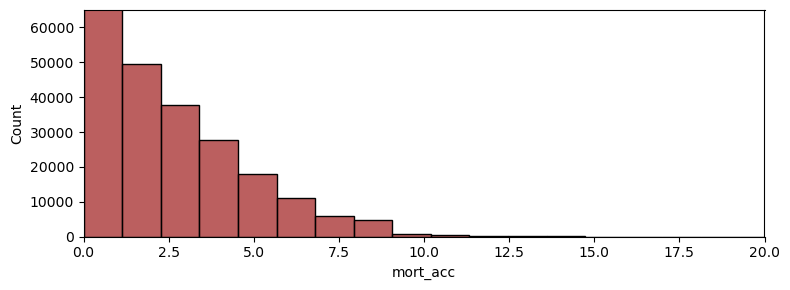

In [13]:
plt.figure(figsize=(8,3))

sns.histplot(df['mort_acc'],color='brown',bins=30)
plt.xlim(0,20)
plt.ylim(0,65000)

plt.tight_layout()
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1;">

Distributions are not normal and hence replacing the null values with median

In [14]:
# Imputing missing values in mort_acc with median
total_acc_median =df.groupby('total_acc')['mort_acc'].median()

def fill_mort_acc(total_acc, mort_acc):
    if np.isnan(mort_acc):
        return total_acc_median[total_acc]
    else:
        return mort_acc
        
df['mort_acc'] = df.apply(lambda x: fill_mort_acc(x['total_acc'], x['mort_acc']), axis=1)

In [15]:
print("There are {} null values left in the dataset".format(df.isnull().sum().sum()))

There are 0 null values left in the dataset


<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1;">

Null values are thus replaced with median and mode values.

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1;">

**Correcting inconsistent data formats (using regex)**
>
>'terms' column contains values like '36 months', '60 months'

>'emp_length' column contains values like '10+ years', '4 years', '< 1 year' etc

In [16]:
# fixing the values in 'term' column - extracting the number and converting to int datatype
df['term'] = df['term'].str.extract(r"(\d+)").astype(int)

In [17]:
# fixing the values in 'emp_length' column using regex 

# creating a temporary column 'emp_length_num' with extracted values ('10', '4', '1'....)
df['emp_length_num'] = df['emp_length'].str.extract(r"(\d+)")

# targets any row where the 'emp_length' contains '< 1' and overwrites the extracted 1 in 'emp_length_num' with a 0, so that <1=0 and 1=1
df.loc[df['emp_length'].str.contains('< 1', na=False), 'emp_length_num'] = 0

In [18]:
# adding the values in the temporary column to emp_length column and deleting the temporary column
df['emp_length']=df['emp_length_num'].astype(int)
df.drop('emp_length_num', axis=1, inplace=True)

In [19]:
df['emp_length'].unique()

array([10,  4,  0,  6,  9,  2,  3,  8,  7,  5,  1])

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

**Checking data imbalance**

> Data imbalance happens when the target classes aren't represented equally. Most machine learning algorithms are designed to minimize the overall error. If one class dominates the other, the model will spend all its energy learning the patterns of majority class and treats the minority class as "exceptions" or "noise."


In [20]:
# checking proportion of each category in target variable
round(df['loan_status'].value_counts(normalize=True)*100.0,2)

loan_status
Fully Paid     80.38
Charged Off    19.62
Name: proportion, dtype: float64

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

**Key Observations**

>It is clear that the target variable is imbalanced with 'Fully Paid' dominating (80.38%) over 'Charged Off'(19.62%).

> Data imbalance makes our model prone to Type II errors (False Negatives)—In our dataset the model may become too optimistic and misses the red flags of a default.
>
> So it should be taken care off before model building using techniques like oversampling/undersampling/SMOTE etc
>
> **Note:** Full Paid means the borrower has completely repaid the amount; Charged Off means the lender wrote off the debt as a loss after months of no payment (usually 180 days).

<div style="font-family: 'Consolas'; color: #800000; font-size: 20px; line-height: 1.5;">

**Univariate Analysis**

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">

>**Numeric Columns**

In [21]:
df.select_dtypes(include=['number']).columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
       'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'mort_acc', 'pub_rec_bankruptcies'],
      dtype='object')

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

>**checking distributions & outliers**

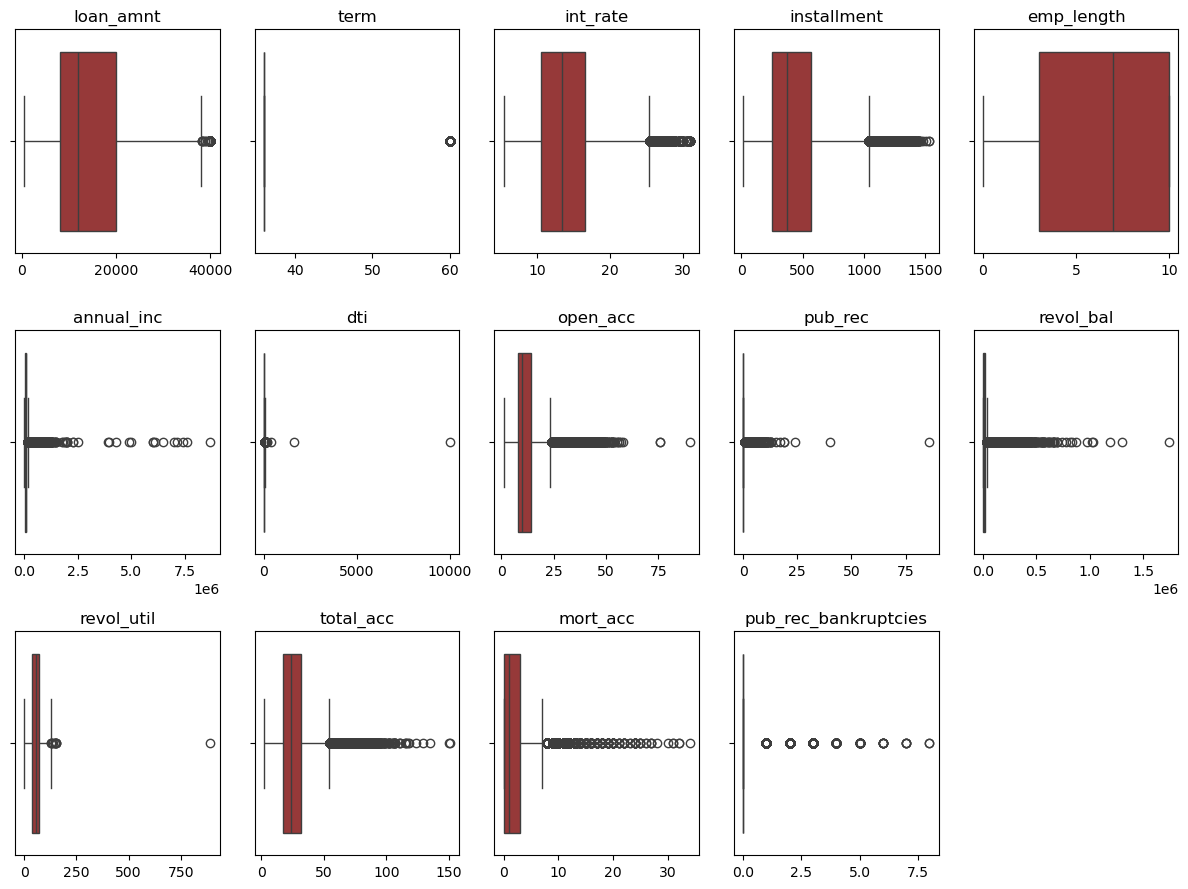

In [22]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = df.select_dtypes(include=['number']).columns 

# setting the canvas for plotting
n_cols = 5
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df[col], ax=axes[i], color='brown')
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

# Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

**Key Observations**

> There are extreme outliers ('annual_inc', 'revol_bal', 'loan_amnt', 'installment') that are stretching the x-axis scale so far that the "normal" data (where 99% are) becomes invisible. Logistic Regression cannot handle a feature where some values are 1000 X larger than the mean. We need to apply ***log transformation*** on such columns so that it will "stretch" small values and "squash" large ones, turning a long-tailed distribution into a more symmetrical one. 
>
> There are long right tails ('total_acc', 'open_acc', 'mort_acc') that can have too much "leverage" and may bias the coefficients. ***Capping (Winsorizing)*** at the 95th or 99th percentile is best here. It keeps the "high-risk" signal without the extreme distance.
>
>'term', 'int_rate', 'emp_length' are genuine cases. So there is no need of filtering or clipping these values as these are mportant signals. 

>'pub_rec_bankruptcies', 'pub_rec' are features that track different types of "derogatory" events in a person's legal and credit history. They are mostly zeros because most borrowers in a bank's dataset have no history of legal financial trouble. When someone does have a record, it’s a high-risk signal, which is why the box plot flagged them as outliers—they are statistically rare but highly important for risk modeling.
>
>**'dti'** feature - Debt-to-Income (DTI) ratio is a financial metric that compares monthly debt obligations to gross monthly income. So dti of 10000 is impossible and could be a data entry mistake. So filtering them out with dti <= 100 will make the model more reliable.
>
>**'revol_util'** feature - represents the percentage of credit used relative to the limit, values above 100% are physically possible (e.g., someone overdrawing their limit), but they are rare and represent extreme risk.

In [23]:
# making a copy of df before transforming
df_copy = df.copy()

In [24]:
## 1. Log Transform the "Money" features
for col in ['annual_inc', 'revol_bal', 'loan_amnt', 'installment']:
    df[col] = np.log1p(df[col])

# 2. Cap the "Account" features at the 99th percentile
for col in ['total_acc', 'open_acc', 'mort_acc']:
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper_limit)

# filtering rows with dti<=100
df = df[df['dti'] <= 100]

# clipping 'revol_util' at 100
df['revol_util'] = df['revol_util'].clip(upper=100)

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

>Rechecking the box plot after outlier handling

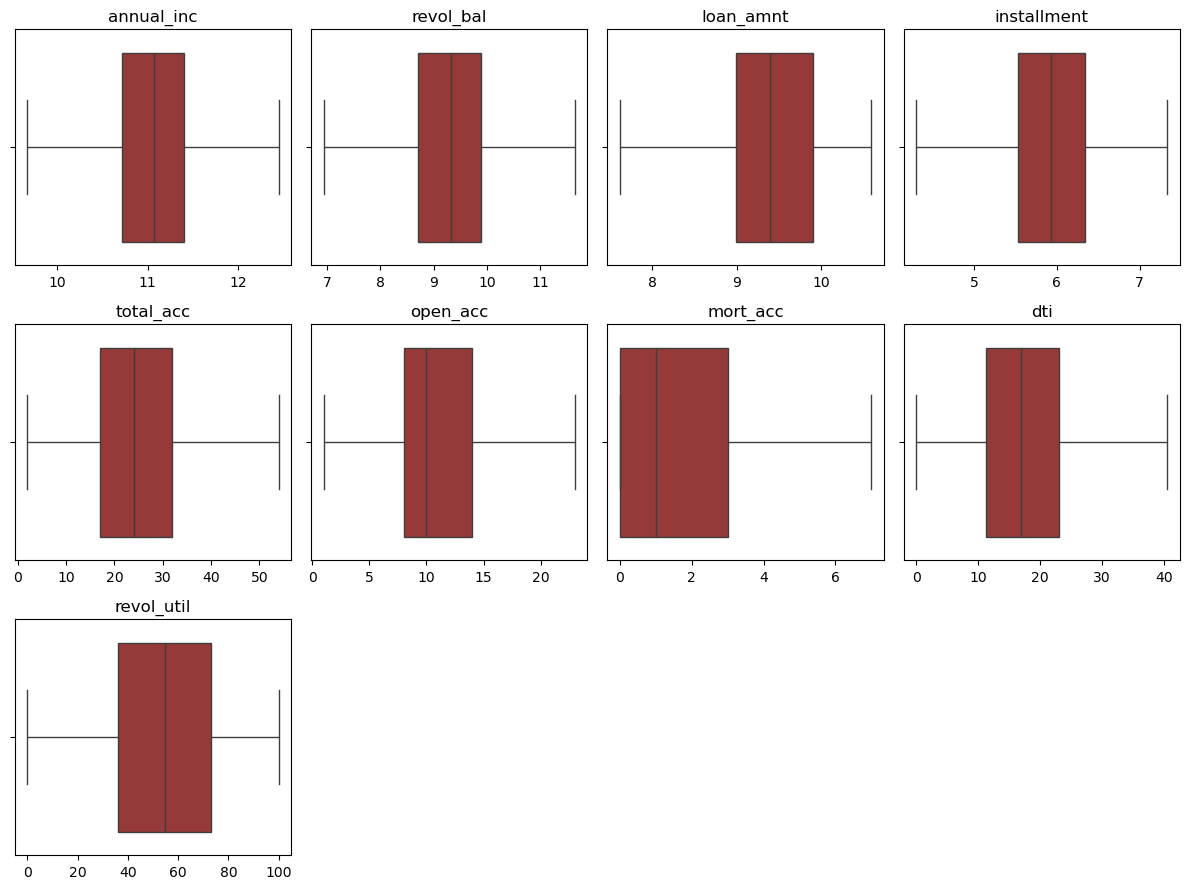

In [25]:
cols_to_plot = ['annual_inc', 'revol_bal', 'loan_amnt', 'installment', 
                'total_acc', 'open_acc', 'mort_acc', 'dti', 'revol_util']

# setting the canvas for plotting
n_cols = 4
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df[col], ax=axes[i], color='brown',showfliers=False)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

# Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

Remaining numerical columns whch are categorical in nature

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

>pub_rec_bankruptcies

In [26]:
df['pub_rec_bankruptcies'].value_counts()

pub_rec_bankruptcies
0.0    348591
1.0     42554
2.0      1837
3.0       347
4.0        82
5.0        32
6.0         7
7.0         4
8.0         2
Name: count, dtype: int64

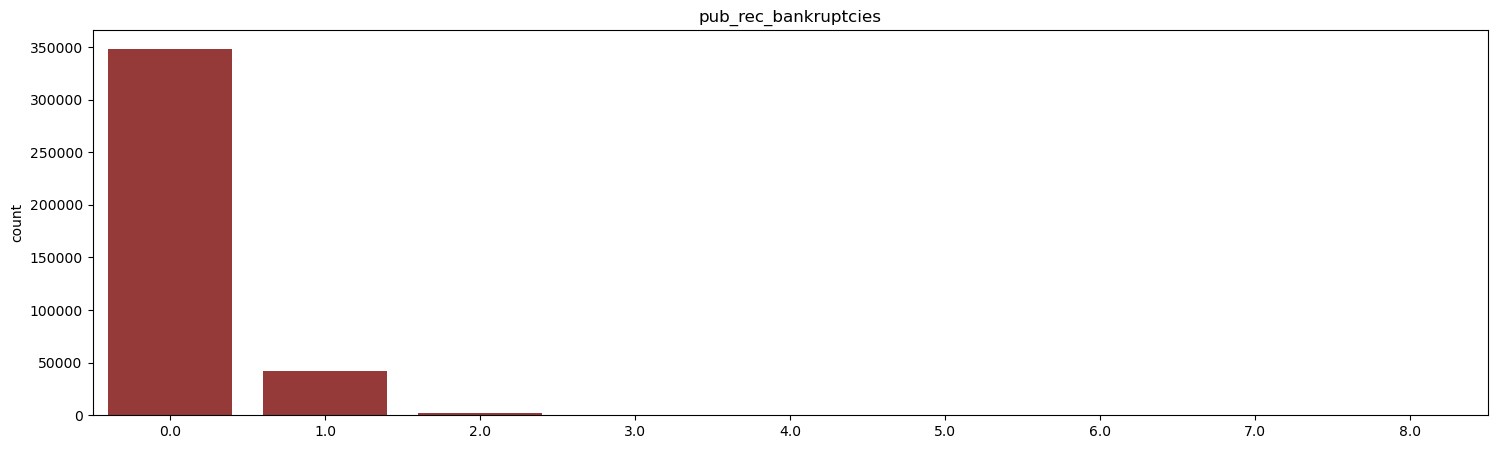

In [27]:
#Checking frequencies of 'pub_rec_bankruptcies'
plt.figure(figsize=(18,5))
sns.countplot(x='pub_rec_bankruptcies', data=df,color='brown')
plt.xlabel("")
plt.title('pub_rec_bankruptcies')
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

>pub_rec

In [28]:
df['pub_rec'].value_counts()

pub_rec
0.0     336066
1.0      49423
2.0       5444
3.0       1509
4.0        523
5.0        235
6.0        121
7.0         56
8.0         34
9.0         12
10.0        11
11.0         7
13.0         4
12.0         4
19.0         2
40.0         1
17.0         1
86.0         1
24.0         1
15.0         1
Name: count, dtype: int64

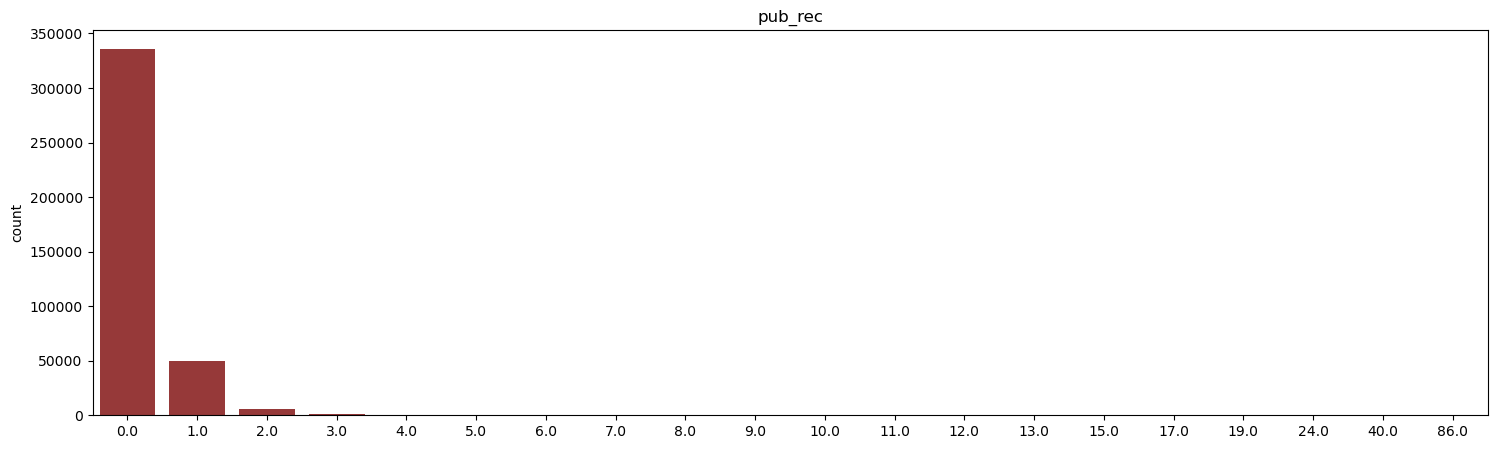

In [29]:
#Checking frequencies of 'pub_rec_bankruptcies'
plt.figure(figsize=(18,5))
sns.countplot(x='pub_rec', data=df,color='brown')
plt.xlabel("")
plt.title('pub_rec')
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

**Comments on above two count plots:**
>
>In both plots, it is seen that approx 85%-90% data is 0.0. So the model will naturally find it easier to "learn" about people with zero bankruptcies or public records than those with one or two. In such cases,  a model could simply guess 0.0 for everyone and be 90% accurate.  It would be "accurate" but totally useless because it fails to catch the **"high-risk individuals"** (the 1s and 2s) which are the ones the bank actually cares about.
>
>So care should be taken while interpreting the metrics after training the model.

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">

>**Categorical Columns**

In [30]:
cols = df.select_dtypes(include=['object']).columns
cols

Index(['grade', 'sub_grade', 'emp_title', 'home_ownership',
       'verification_status', 'issue_d', 'purpose', 'title',
       'earliest_cr_line', 'initial_list_status', 'application_type',
       'address', 'loan_status'],
      dtype='object')

In [31]:
# converting issue_d and earliest_cr_line to datetime as they are dates by nature
df['issue_d'] = pd.to_datetime(df['issue_d'],format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'],format='%b-%Y')

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

grade
>
>A - highest grade, lowest risk of default
>
>G - lowest grade, highest risk of default

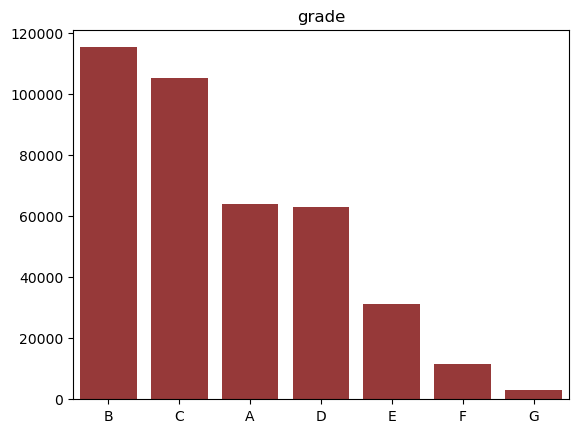

In [32]:
sns.barplot(x=df['grade'].value_counts().index, y=df['grade'].value_counts().values,color='brown')
plt.xlabel("")
plt.title("grade")
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

> grade B  tops the list with C preceding. Though A is the highest grade, it comes with stringent criteria because of which fewer applicants qualify for it.
>
> Because of the perfect balance between the risk of default and profit margin grade B & C loans are higher than top-tier Grade A loans.

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

sub_grade - *"magnifying glass for the grade column"*

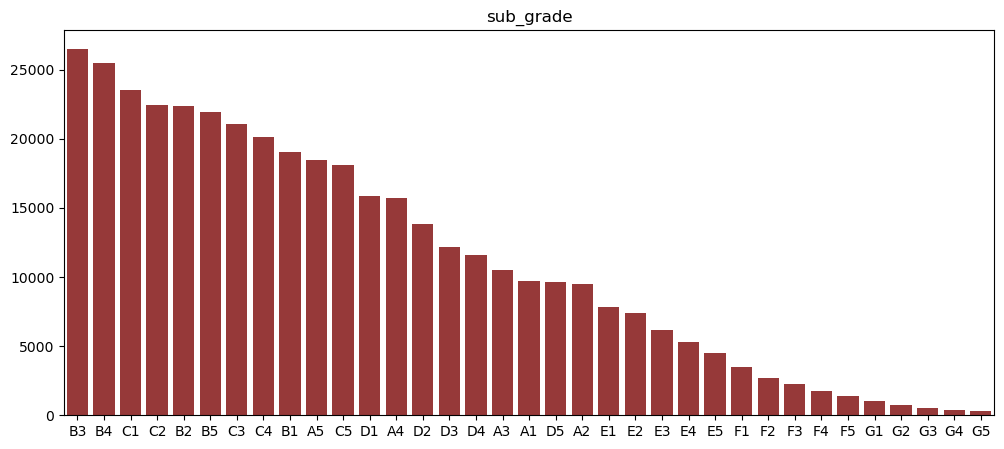

In [33]:
plt.figure(figsize=(12,5))
sns.barplot(x=df['sub_grade'].value_counts().index, y=df['sub_grade'].value_counts().values,color='brown')
plt.xlabel("")
plt.title("sub_grade")
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

> As expected, most of the top sub_grades are from B & C grades

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

emp_title

In [34]:
# checking unique values in employment titles of borrowers
df['emp_title'].nunique()

172224

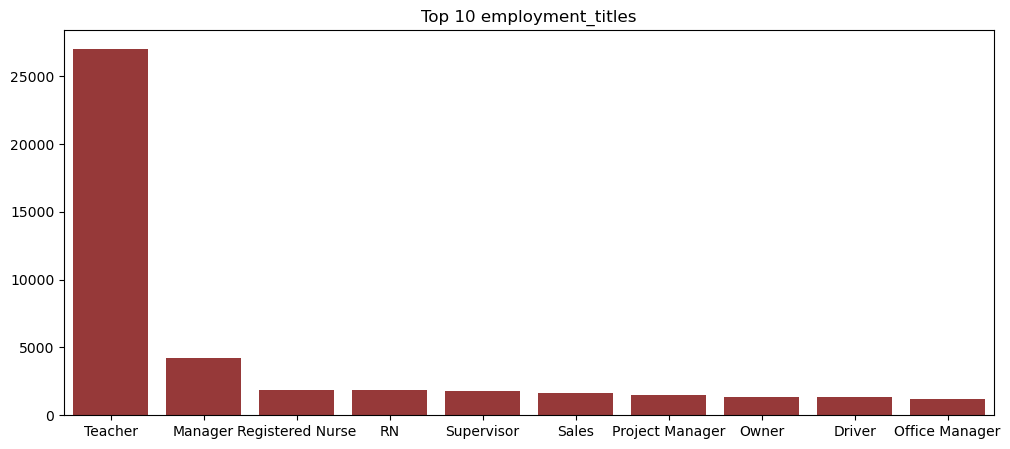

In [35]:
# top 10 borrowers by profession
plt.figure(figsize=(12,5))
sns.barplot(x=df['emp_title'].value_counts().index[0:10], y=df['emp_title'].value_counts().values[0:10] ,color='brown')
plt.title("Top 10 employment_titles")
plt.xlabel("")
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

> Most of the borrowers are teachers (approx 70%)

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

home_ownership

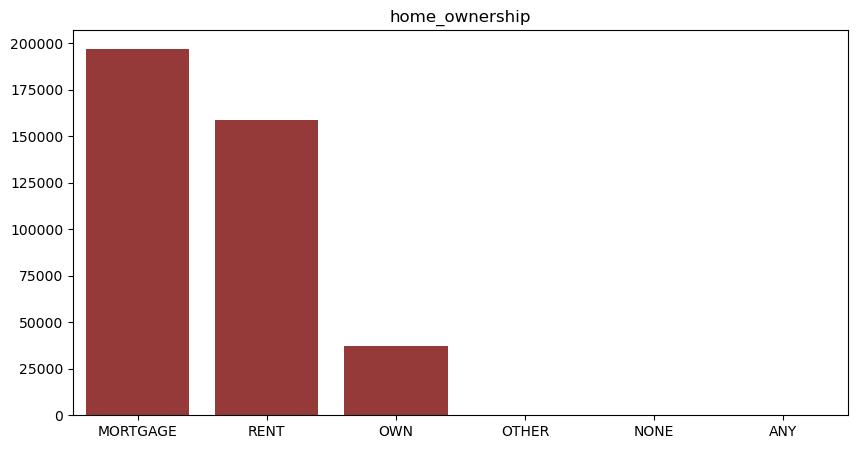

In [36]:
plt.figure(figsize=(10,5))
sns.barplot(x=df['home_ownership'].value_counts().index, y=df['home_ownership'].value_counts().values,color='brown')
plt.title("home_ownership")
plt.xlabel("")
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

> mortgage - Individuals who are actively paying off a large, long-term loan to a bank while applying for another personal loan
>
> rent - The individual pays a monthly rent for temporary housing.
>
> own - The individual owns the home completely free with zero outstanding loan balance.
>
> So, most of the borrowers were already in a loan repayment commitment while applying the loan.

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

verification_status - Indicates if income was verified by LoanTap, not verified, or if the income source was verified

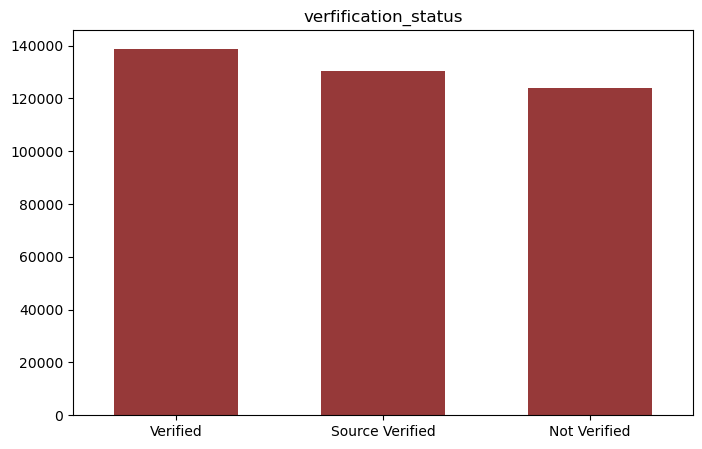

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(x=df['verification_status'].value_counts().index, y=df['verification_status'].value_counts().values,color='brown',width=0.6)
plt.title("verfification_status")
plt.xlabel("")
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

>A large chunk of borrowers' income are not verified by LoanTap that means the income was purely self-reported by the borrower and was not independently audited or checked against official documents.
>
> as a calculated risk, such borrowers might have offered small loans or was charged with high interest rates.

In [38]:
#since 'loan_amnt is log-transformed in original df, we will use df_copy
print(df_copy.groupby('verification_status')['loan_amnt'].median())

verification_status
Not Verified       10000.0
Source Verified    13000.0
Verified           15350.0
Name: loan_amnt, dtype: float64


In [39]:
print(df_copy.groupby('verification_status')['int_rate'].median())

verification_status
Not Verified       12.12
Source Verified    13.35
Verified           14.33
Name: int_rate, dtype: float64


<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

> though the 'not verified' individuals/borrowers were offered lesser loan amount, they were charged with lesser interest rate too. This can be attributed to their excellent credit score, long credit history, and a reasonable loan request.

In [40]:
# checking indiviuals median credit history 
df_copy = df.copy()
df_copy['credit_history_days'] = df_copy['issue_d'] - df_copy['earliest_cr_line']

result = df_copy.groupby('verification_status')['credit_history_days'].median()
print(result)

verification_status
Not Verified      4991 days
Source Verified   5235 days
Verified          5507 days
Name: credit_history_days, dtype: timedelta64[ns]


<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

> it is now clear that these 'not verified' borrowers has good credit history too.

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

purpose

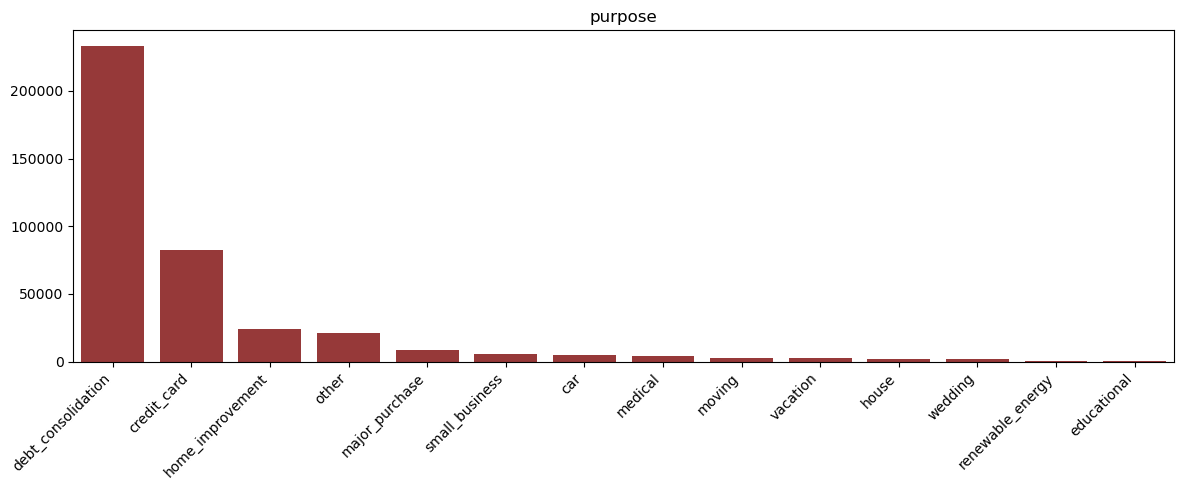

In [41]:
plt.figure(figsize=(12,5))
sns.barplot(x=df['purpose'].value_counts().index, y=df['purpose'].value_counts().values,color='brown')
plt.xticks(rotation=45,ha='right')
plt.xlabel("")
plt.title("purpose")
plt.tight_layout()
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

title

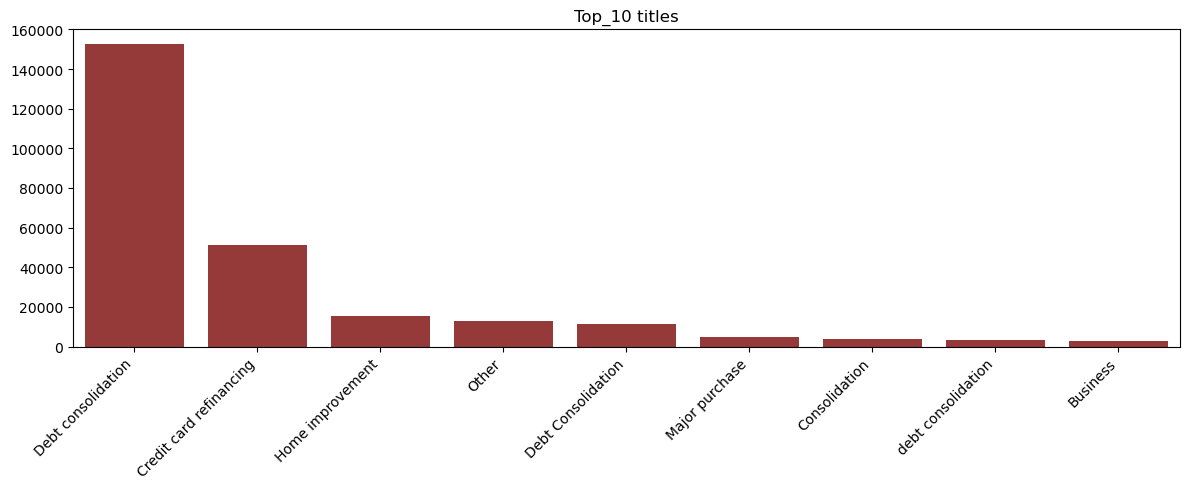

In [42]:
plt.figure(figsize=(12,5))
sns.barplot(x=df['title'].value_counts().index[0:9], y=df['title'].value_counts().values[0:9],color='brown')
plt.xticks(rotation=45,ha='right')
plt.xlabel("")
plt.title("Top_10 titles")
plt.tight_layout()
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

>though there are data inconsistencies like 'Debt consolidation' and Debt Consolidation', overall debt consolidation tops the list

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

initial_list_status

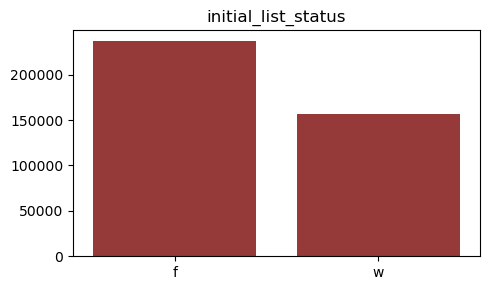

In [43]:
plt.figure(figsize=(5,3))
sns.barplot(x=df['initial_list_status'].value_counts().index, y=df['initial_list_status'].value_counts().values,color='brown')
plt.xlabel("")
plt.title("initial_list_status")
plt.tight_layout()
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

application_type

In [44]:
df['application_type'].value_counts(normalize=True)

application_type
INDIVIDUAL    0.998442
JOINT         0.000884
DIRECT_PAY    0.000674
Name: proportion, dtype: float64

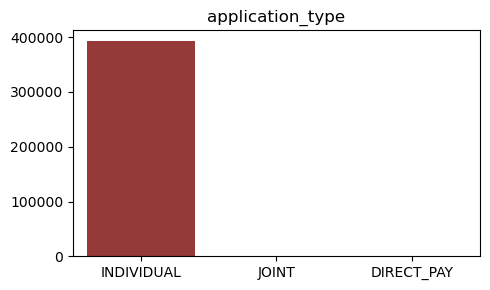

In [45]:
plt.figure(figsize=(5,3))
sns.barplot(x=df['application_type'].value_counts().index, y=df['application_type'].value_counts().values,color='brown')
plt.xlabel("")
plt.title("application_type")
plt.tight_layout()
plt.show()

In [46]:
print(df.groupby("application_type")["loan_status"].value_counts(normalize=True))

application_type  loan_status
DIRECT_PAY        Fully Paid     0.660377
                  Charged Off    0.339623
INDIVIDUAL        Fully Paid     0.803838
                  Charged Off    0.196162
JOINT             Fully Paid     0.879310
                  Charged Off    0.120690
Name: proportion, dtype: float64


<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

**Key Observations**

> While DIRECT_PAY and JOINT have a tiny sample size, their behavior is vastly different from the standard INDIVIDUAL application.
>
> DIRECT_PAY: These applicants are highly risky. They default (Charged Off) at a rate of ~35.7%. This is almost double the default rate of individual applicants.
>
> INDIVIDUAL: a standard default rate of ~19.6%.
>
> JOINT: These applicants are safest borrowers, defaulting at a rate of only ~12.7%.
>
> So, 'individual' & 'joint' contain highly valuable predictive power and hence cannot be removed from the dataset just because of its tiny sample size

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 3;">
    
issue_d - The month which the loan was funded

In [47]:
df['issue_d'].dt.year.value_counts()

issue_d
2014    102795
2013     97594
2015     94189
2012     41168
2016     26345
2011     17427
2010      9231
2009      3813
2008       889
2007         5
Name: count, dtype: int64

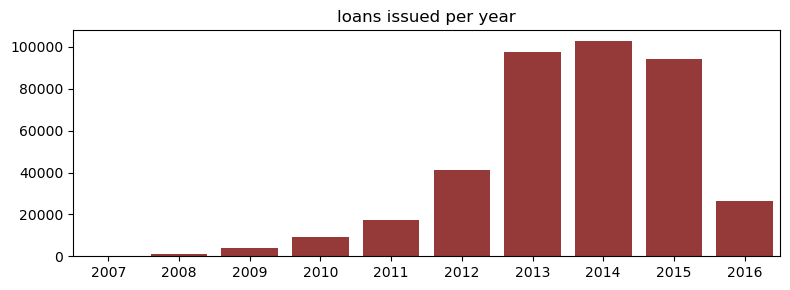

In [48]:
plt.figure(figsize=(8,3))
sns.barplot(x=df['issue_d'].dt.year.value_counts().index, y=df['issue_d'].dt.year.value_counts().values,color='brown')
plt.xlabel("")
plt.title("loans issued per year")
plt.tight_layout()
plt.show()

In [49]:
# checking proportion of closed loans and defaulted loans(written off) in each year

df_copy['issue_d_year'] = df['issue_d'].dt.year
print(df_copy.groupby("issue_d_year")["loan_status"].value_counts(normalize=True))

issue_d_year  loan_status
2007          Fully Paid     0.600000
              Charged Off    0.400000
2008          Fully Paid     0.847019
              Charged Off    0.152981
2009          Fully Paid     0.878049
              Charged Off    0.121951
2010          Fully Paid     0.868162
              Charged Off    0.131838
2011          Fully Paid     0.847650
              Charged Off    0.152350
2012          Fully Paid     0.835285
              Charged Off    0.164715
2013          Fully Paid     0.842583
              Charged Off    0.157417
2014          Fully Paid     0.768890
              Charged Off    0.231110
2015          Fully Paid     0.750958
              Charged Off    0.249042
2016          Fully Paid     0.872462
              Charged Off    0.127538
Name: proportion, dtype: float64


In [50]:
# pivoting
pivoted_df = df_copy.groupby("issue_d_year")["loan_status"].value_counts(normalize=True).unstack().reset_index()

# converting issue_d_year to int
pivoted_df['issue_d_year'] = pivoted_df['issue_d_year'].astype(int)

# removing axis_name - loan_status
pivoted_df = pivoted_df.rename_axis(columns=None)
print(pivoted_df)

   issue_d_year  Charged Off  Fully Paid
0          2007     0.400000    0.600000
1          2008     0.152981    0.847019
2          2009     0.121951    0.878049
3          2010     0.131838    0.868162
4          2011     0.152350    0.847650
5          2012     0.164715    0.835285
6          2013     0.157417    0.842583
7          2014     0.231110    0.768890
8          2015     0.249042    0.750958
9          2016     0.127538    0.872462


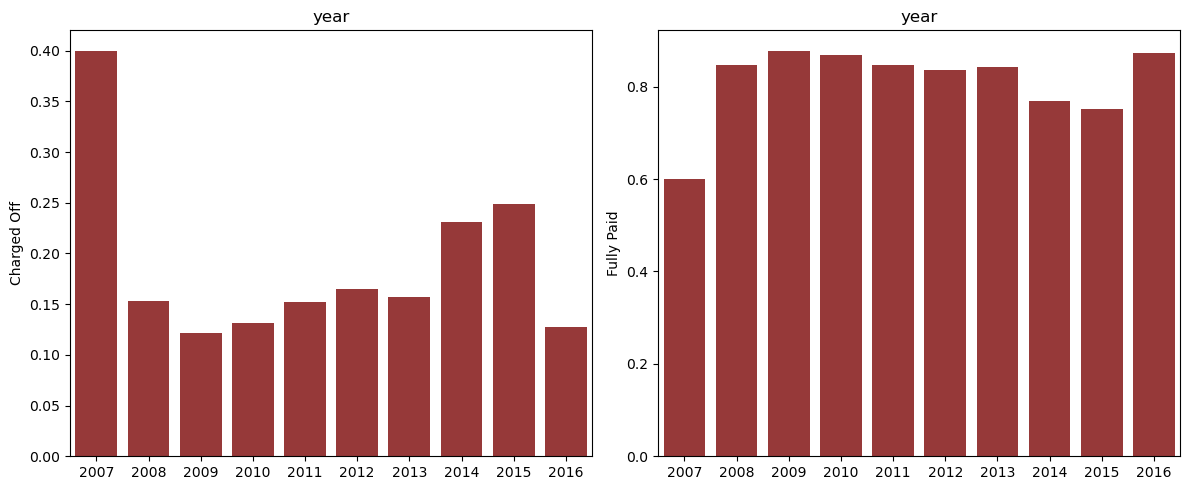

In [51]:
X = pivoted_df['issue_d_year']
cols = ['Charged Off','Fully Paid']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(2):
    sns.barplot(x=X, y= pivoted_df.iloc[:,i+1],ax=axes[i], color='brown')
    axes[i].set_title("year")
    axes[i].set_xlabel('')
    axes[i].set_ylabel(f'{cols[i]}')
plt.tight_layout()
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

> 2007 - largest number of defaults
> 
> 2016 - lowest number of defaults

In [52]:
pivoted_df = df_copy.groupby("issue_d_year")["loan_status"].value_counts().unstack().reset_index()

# converting issue_d_year to int
pivoted_df['issue_d_year'] = pivoted_df['issue_d_year'].astype(int)

# removing axis_name - loan_status
pivoted_df = pivoted_df.rename_axis(columns=None)
print(pivoted_df)

   issue_d_year  Charged Off  Fully Paid
0          2007            2           3
1          2008          136         753
2          2009          465        3348
3          2010         1217        8014
4          2011         2655       14772
5          2012         6781       34387
6          2013        15363       82231
7          2014        23757       79038
8          2015        23457       70732
9          2016         3360       22985


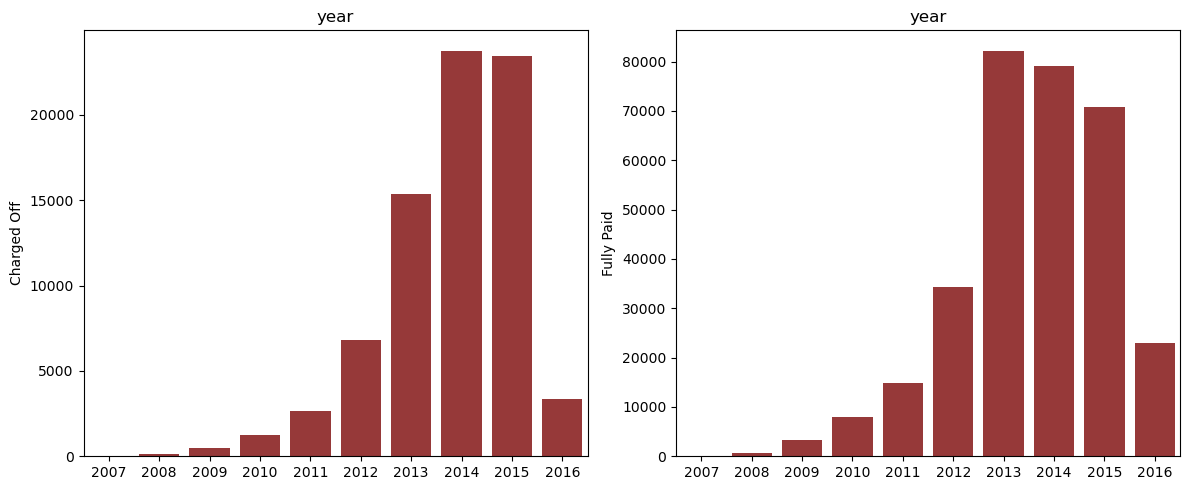

In [53]:
X = pivoted_df['issue_d_year']
cols = ['Charged Off','Fully Paid']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(2):
    sns.barplot(x=X, y= pivoted_df.iloc[:,i+1],ax=axes[i], color='brown')
    axes[i].set_title("year")
    axes[i].set_xlabel('')
    axes[i].set_ylabel(f'{cols[i]}')
plt.tight_layout()
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

> 2013,2014,2015 - largest number of loan approvals
> 
> 2007 - lowest number of loan approvals

<div style="font-family: 'Consolas'; color: #800000; font-size: 20px; line-height: 1;">

**Bivariate Analysis**

<div style="font-family: 'Consolas'; color: #800000; font-size: 17px; line-height: 1;">

categorical variable vs target variable

In [54]:
cols = df.select_dtypes(include=['object']).columns
cols

Index(['grade', 'sub_grade', 'emp_title', 'home_ownership',
       'verification_status', 'purpose', 'title', 'initial_list_status',
       'application_type', 'address', 'loan_status'],
      dtype='object')

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

grade vs loan_status

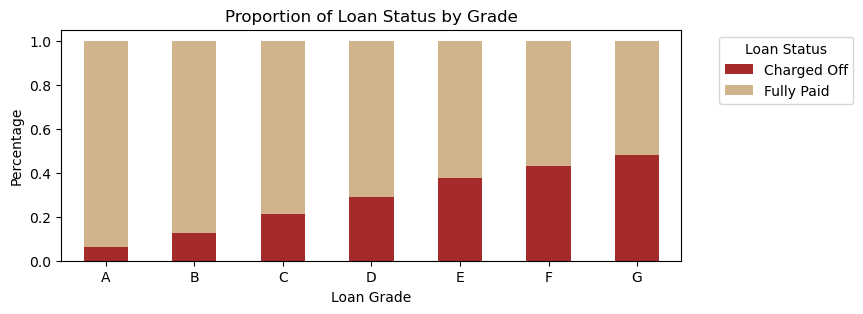

In [55]:
ct = pd.crosstab(df["grade"], df["loan_status"], normalize="index")

ct.plot(kind="bar", stacked=True, figsize=(8,3), color=["brown", "tan"])
plt.title("Proportion of Loan Status by Grade")
plt.ylabel("Percentage")
plt.xlabel("Loan Grade")
plt.xticks(rotation=0)
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1))
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

home_ownership vs loan_status

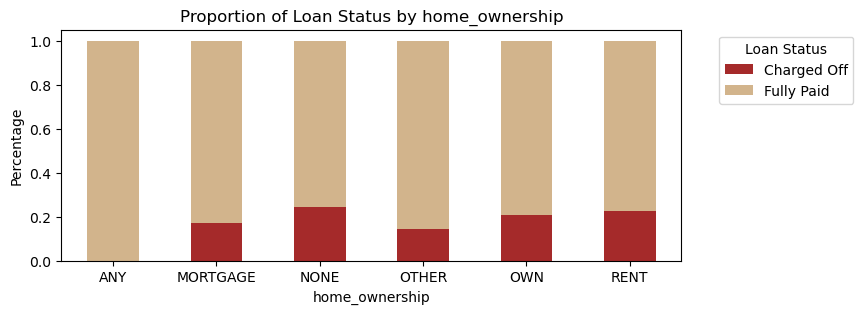

In [56]:
ct = pd.crosstab(df["home_ownership"], df["loan_status"], normalize="index")

ct.plot(kind="bar", stacked=True, figsize=(8,3), color=["brown", "tan"])
plt.title("Proportion of Loan Status by home_ownership")
plt.ylabel("Percentage")
plt.xlabel("home_ownership")
plt.xticks(rotation=0)
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1))
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

verification_status vs loan_status

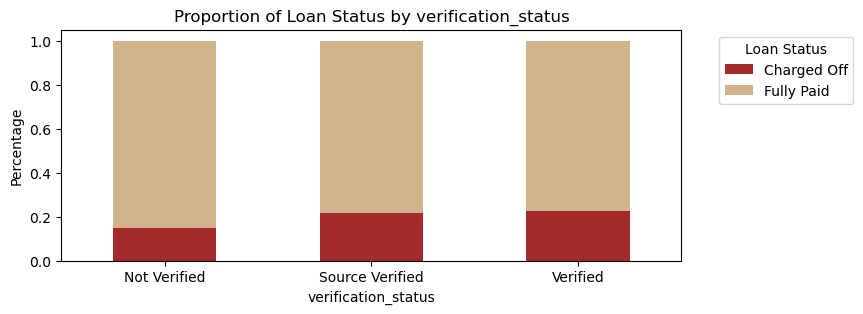

In [57]:
ct = pd.crosstab(df["verification_status"], df["loan_status"], normalize="index")

ct.plot(kind="bar", stacked=True, figsize=(8, 3), color=["brown", "tan"])
plt.title("Proportion of Loan Status by verification_status")
plt.ylabel("Percentage")
plt.xlabel("verification_status")
plt.xticks(rotation=0)
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1))
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

purpose vs loan_status

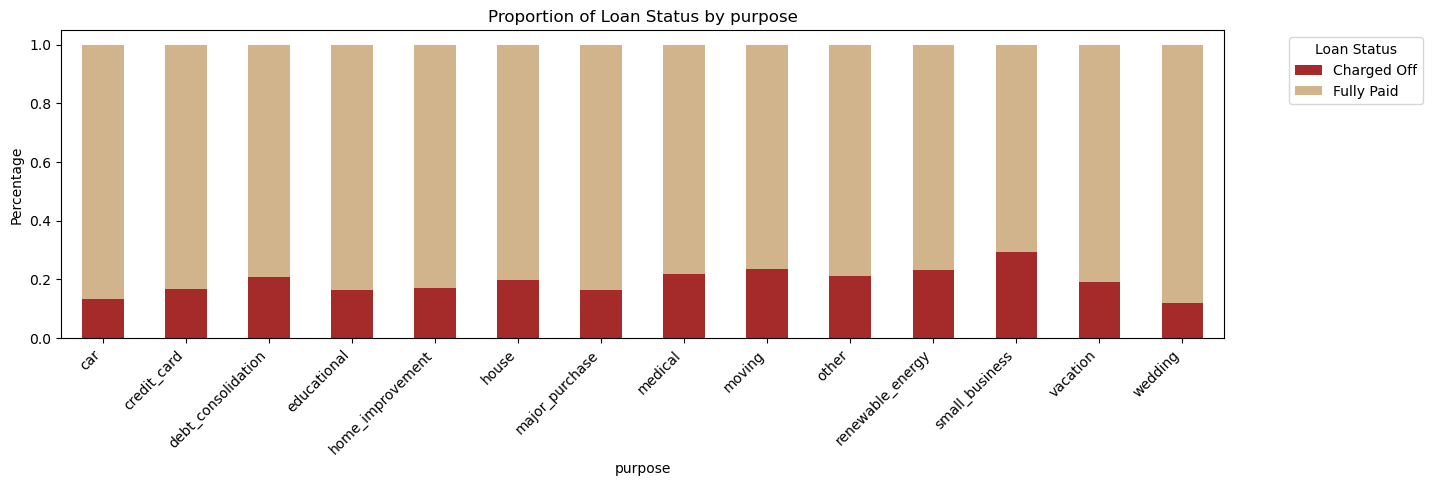

In [58]:
ct = pd.crosstab(df["purpose"], df["loan_status"], normalize="index")

ct.plot(kind="bar", stacked=True, figsize=(15, 4), color=["brown", "tan"])
plt.title("Proportion of Loan Status by purpose")
plt.ylabel("Percentage")
plt.xlabel("purpose")
plt.xticks(rotation=45,ha='right')
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1))
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

emp_title vs loan_status

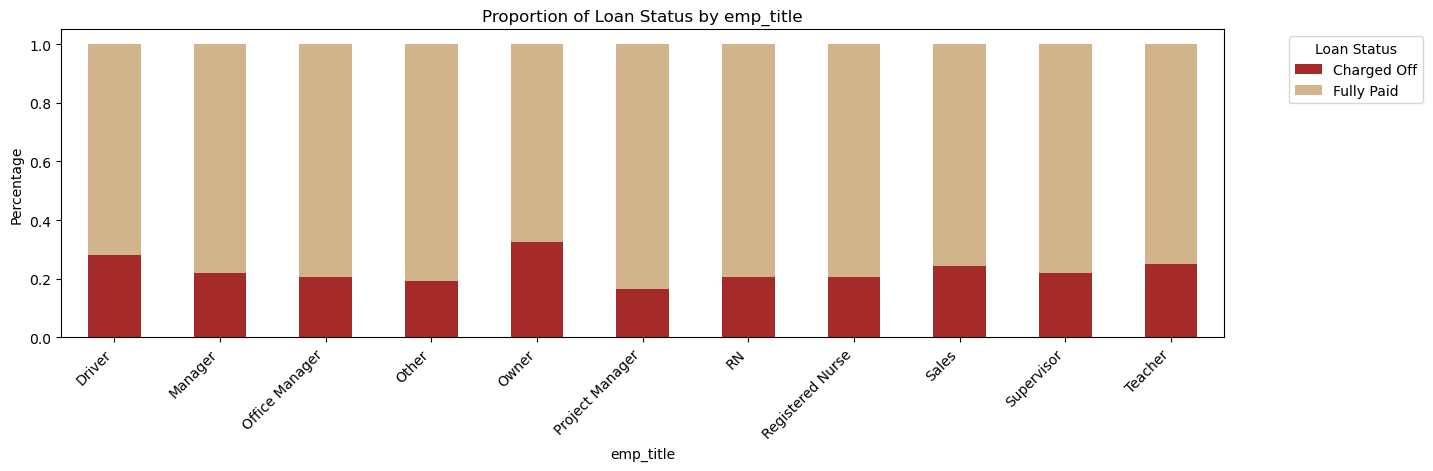

In [59]:
top_10 = df_copy['emp_title'].value_counts().nlargest(10).index

# 2. Group the rest as 'Other'
df_copy['emp_title_grouped'] = df_copy['emp_title'].apply(
    lambda x: x if x in top_10 else 'Other'
)

# 3. Perform standard cross-tabulation
ct = pd.crosstab(df_copy['emp_title_grouped'], df_copy['loan_status'], normalize='index')


ct.plot(kind="bar", stacked=True, figsize=(15, 4), color=["brown", "tan"])
plt.title("Proportion of Loan Status by emp_title")
plt.ylabel("Percentage")
plt.xlabel("emp_title")
plt.xticks(rotation=45,ha='right')
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1))
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

title vs loan_status

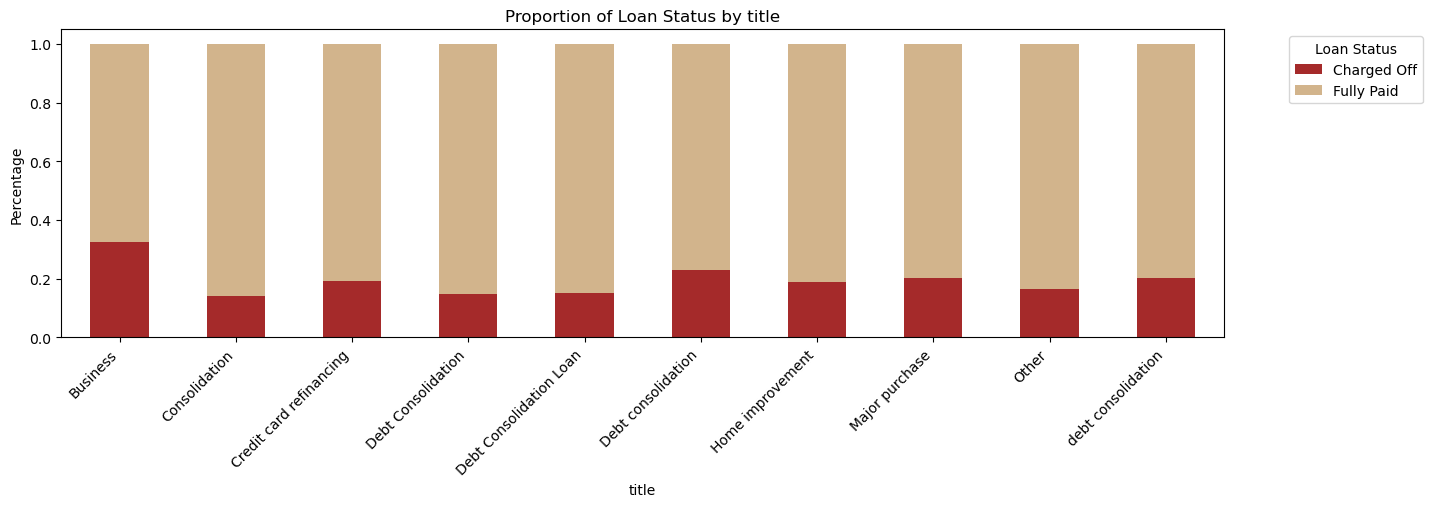

In [60]:
top_10 = df_copy['title'].value_counts().nlargest(10).index

# 2. Group the rest as 'Other'
df_copy['title_grouped'] = df_copy['title'].apply(
    lambda x: x if x in top_10 else 'Other'
)

# 3. Perform standard cross-tabulation
ct = pd.crosstab(df_copy['title_grouped'], df_copy['loan_status'], normalize='index')


ct.plot(kind="bar", stacked=True, figsize=(15, 4), color=["brown", "tan"])
plt.title("Proportion of Loan Status by title")
plt.ylabel("Percentage")
plt.xlabel("title")
plt.xticks(rotation=45,ha='right')
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1))
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

term vs loan_status

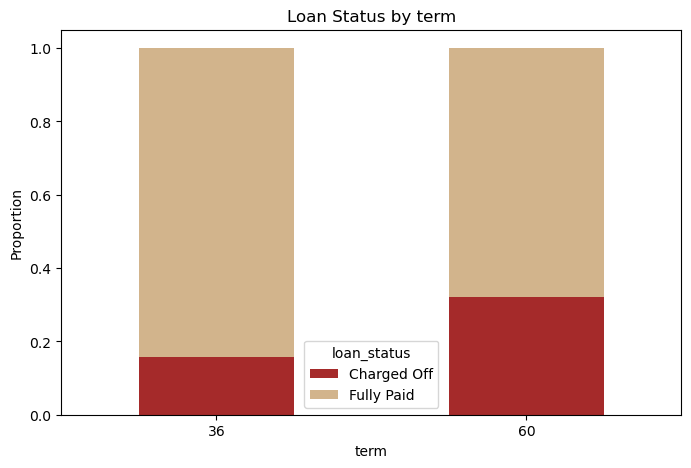

In [61]:
crosstab = pd.crosstab(
    df['term'], 
    df['loan_status'], 
    normalize='index'
)

crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), color=['brown', 'tan'])
plt.title('Loan Status by term')
plt.ylabel('Proportion')
plt.xlabel('term')
plt.xticks(rotation=0)
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

intial_list_status vs loan_status

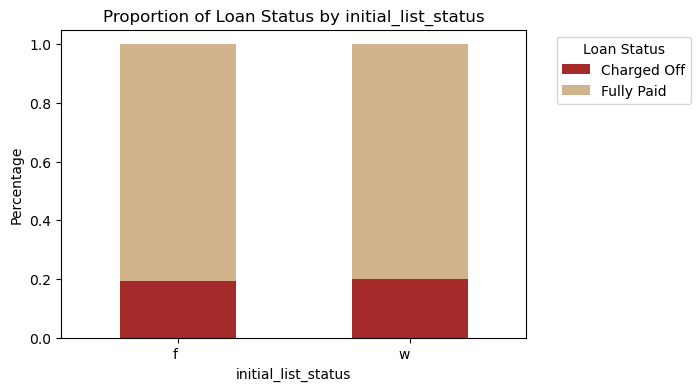

In [62]:
ct = pd.crosstab(df["initial_list_status"], df["loan_status"], normalize="index")

ct.plot(kind="bar", stacked=True, figsize=(6, 4), color=["brown", "tan"])
plt.title("Proportion of Loan Status by initial_list_status")
plt.ylabel("Percentage")
plt.xlabel("initial_list_status")
plt.xticks(rotation=0,ha='right')
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1))
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

application_type vs loan_status

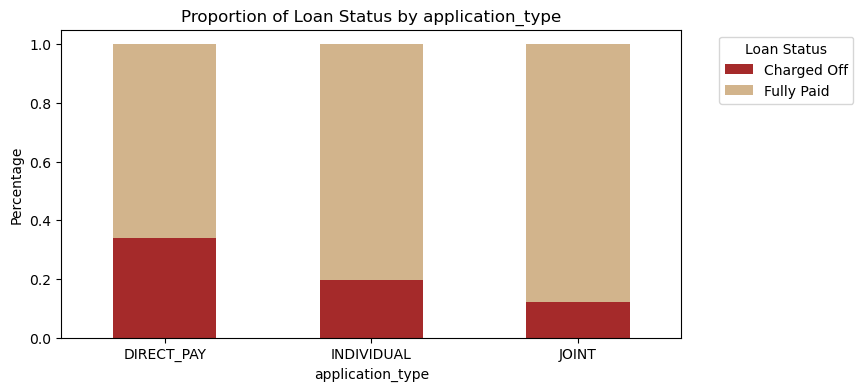

In [63]:
ct = pd.crosstab(df["application_type"], df["loan_status"], normalize="index")

ct.plot(kind="bar", stacked=True, figsize=(8, 4), color=["brown", "tan"])
plt.title("Proportion of Loan Status by application_type")
plt.ylabel("Percentage")
plt.xlabel("application_type")
plt.xticks(rotation=0)
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1))
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1;">

numerical variable vs target variable

In [64]:
cols = df.select_dtypes(include=['number']).columns
cols

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
       'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'mort_acc', 'pub_rec_bankruptcies'],
      dtype='object')

In [65]:
# converting target variable into numerical
#df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393456 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   loan_amnt             393456 non-null  float64       
 1   term                  393456 non-null  int64         
 2   int_rate              393456 non-null  float64       
 3   installment           393456 non-null  float64       
 4   grade                 393456 non-null  object        
 5   sub_grade             393456 non-null  object        
 6   emp_title             393456 non-null  object        
 7   emp_length            393456 non-null  int64         
 8   home_ownership        393456 non-null  object        
 9   annual_inc            393456 non-null  float64       
 10  verification_status   393456 non-null  object        
 11  issue_d               393456 non-null  datetime64[ns]
 12  purpose               393456 non-null  object        
 13  titl

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1;">

> emp_length vs loan_status

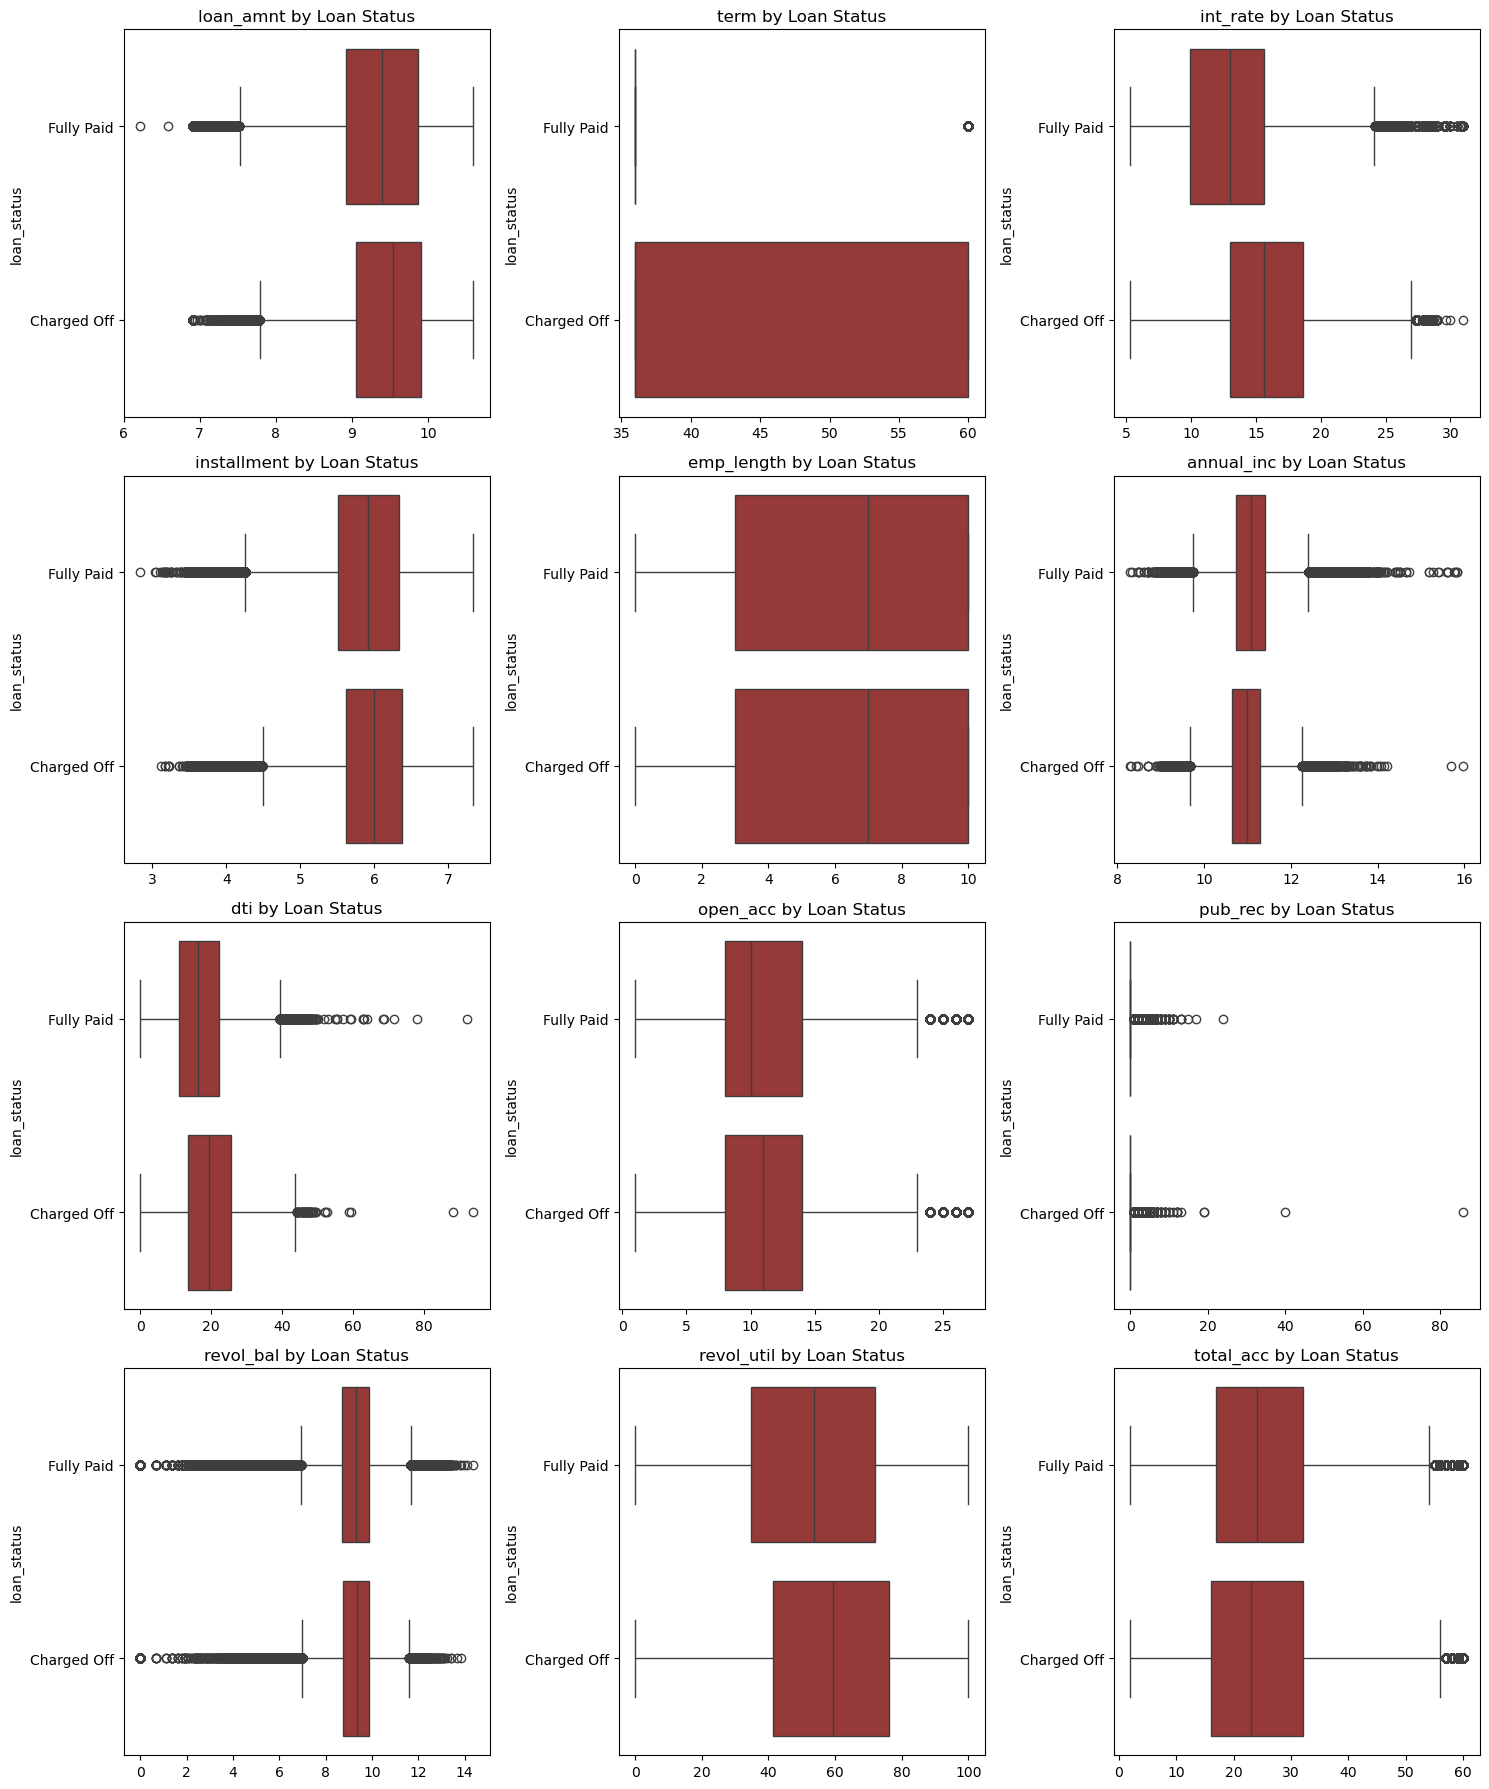

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# selecting numeric columns
cols_to_plot = df.select_dtypes(include=["number"]).columns

# 2. Set up the 4x3 grid
n_rows, n_cols = 4,3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 18))
axes = axes.flatten()  # Flatten to iterate easily

# 3. Loop and plot using the 'ax' parameter
for i, col in enumerate(cols_to_plot):
    if i < len(axes):
        sns.boxplot(x=col, y="loan_status", data=df, color="brown", ax=axes[i])
        axes[i].set_title(f"{col} by Loan Status")
        axes[i].set_xlabel("") # Optional: clean up x-label if title is enough
    
# 4. Hide any empty subplots (if you have fewer than 12 columns)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1;">

**Feature Encoding - Data preparation for Modelling**

In [68]:
# selecting columns of object datatype
df.select_dtypes(include=['object']).info()

<class 'pandas.core.frame.DataFrame'>
Index: 393456 entries, 0 to 396029
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   grade                393456 non-null  object
 1   sub_grade            393456 non-null  object
 2   emp_title            393456 non-null  object
 3   home_ownership       393456 non-null  object
 4   verification_status  393456 non-null  object
 5   purpose              393456 non-null  object
 6   title                393456 non-null  object
 7   initial_list_status  393456 non-null  object
 8   application_type     393456 non-null  object
 9   address              393456 non-null  object
 10  loan_status          393456 non-null  object
dtypes: object(11)
memory usage: 36.0+ MB


<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

Object is the "catch-all" data type for anything that isn't a number or a date. Handling them correctly require understanding the level of data in these columns like ordinal/not ordinal, high/low cardinality, date values etc inorder to apply different techniques to make it consistent for machine learning.

In [69]:
for col in df.select_dtypes('object').columns:
    print(f"{col}:      {df[col].nunique()} unique values")

grade:      7 unique values
sub_grade:      35 unique values
emp_title:      172224 unique values
home_ownership:      6 unique values
verification_status:      3 unique values
purpose:      14 unique values
title:      48471 unique values
initial_list_status:      2 unique values
application_type:      3 unique values
address:      391153 unique values
loan_status:      2 unique values


<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

> 'grade', 'home_ownership', 'verification_status', 'initial_list_status', 'application_type', 'loan_status' are columns with **low cardinality**.

> 'sub_grade', 'emp_title', 'issue_d', 'purpose','title', 'earliest_cr_line' are columns with **high cardinality**

> 'grade' & 'sub_grade' columns have values that assume **some kind of order** such as for e.g A>B & A1>A2 etc

In [70]:
# applying label encoding on 'grade' and 'sub_grade' columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['grade','sub_grade']
for col in cols:
    df[col] = le.fit_transform(df[col])

In [71]:
# Applying one hot encoding on remaining low cardinality columns with no assumed ordinal values except target variable- 
# 'home_ownership', 'verification_status', 'initial_list_status', 'application_type'

ohe_cols = ['home_ownership', 'verification_status', 'initial_list_status', 'application_type']

# 2. Apply OHE (converts text to 0/1 columns)
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

> **drop_first=True :**  If we have k categories, we only need k-1 columns to represent them. For example, if "Gender" has "Male" and "Female," knowing someone is not "Male" (0) implies they are "Female" (1), making the second column redundant. So drop_first=True removes the first generated dummy column for each category to avoid the "Dummy Variable Trap" or multicollinearity.

In [72]:
df.shape

(393456, 33)

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

Note: number of columns increased to 33 after one hot encoding

In [73]:
# encoding target variable
df['loan_status'] = [0 if x=='Fully Paid' else 1 for x in df['loan_status']]

In [74]:
# Transforming columns of high cardinality with target encoding
#P(target_variable = 1|predictor_variable=’’)
#P(target_variable = 0) = 1-(P(target_variable = 1)

from category_encoders import TargetEncoder
# 1. Split the data first! 
# This prevents the test set's target from "leaking" into training features.
X = df.loc[:,('emp_title', 'issue_d', 'title', 'earliest_cr_line','purpose')]
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
encoder = TargetEncoder()

X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

In [75]:
# bringing the encoded values back to original df
cols = ['emp_title', 'issue_d', 'title', 'earliest_cr_line','purpose']
all_encoded = pd.concat([X_train_encoded[cols], X_test_encoded[cols]],axis=0)

all_encoded = all_encoded.add_suffix('_enc')
# Assign it back to the original df
df = df.join(all_encoded)

# Now we can safely drop the old string column
df.drop(columns=cols, axis=1, inplace=True)

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">
    
>**Target Encoding :** It is a supervised feature engineering technique that converts categorical data into numerical values by replacing each category with a statistic derived from the target variable.

In [76]:
all_targets = pd.concat([y_train, y_test], axis=0)

# 2. Convert to Series/DataFrame if it isn't already, and name it
# (Skip this if y_train already has a name like 'loan_status')
all_targets.name = 'loan_status_enc' 

# 3. Join back to the main dataframe
df = df.join(all_targets)

In [77]:
df.drop('loan_status',axis=1,inplace=True)

In [78]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies',
       'address', 'home_ownership_MORTGAGE', 'home_ownership_NONE',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'verification_status_Source Verified', 'verification_status_Verified',
       'initial_list_status_w', 'application_type_INDIVIDUAL',
       'application_type_JOINT', 'emp_title_enc', 'issue_d_enc', 'title_enc',
       'earliest_cr_line_enc', 'purpose_enc', 'loan_status_enc'],
      dtype='object')

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393456 entries, 0 to 396029
Data columns (total 33 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   loan_amnt                            393456 non-null  float64       
 1   term                                 393456 non-null  int64         
 2   int_rate                             393456 non-null  float64       
 3   installment                          393456 non-null  float64       
 4   grade                                393456 non-null  int64         
 5   sub_grade                            393456 non-null  int64         
 6   emp_length                           393456 non-null  int64         
 7   annual_inc                           393456 non-null  float64       
 8   dti                                  393456 non-null  float64       
 9   open_acc                             393456 non-null  float64       
 10  p

In [80]:
df.drop('address',axis=1,inplace=True)

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

**Feature Engineering**

In [81]:
df['year_issue'] = df['issue_d_enc'].dt.year
df['month_issue'] = df['issue_d_enc'].dt.month
df['year_ecl'] = df['earliest_cr_line_enc'].dt.year
df['month_ecl'] = df['earliest_cr_line_enc'].dt.month

In [82]:
# dropping date columns
df.drop(columns=['issue_d_enc','earliest_cr_line_enc'],axis=1,inplace=True)

<div style="font-family: 'Consolas'; color: #800000; font-size: 15px; line-height: 1.5;">

**Checking correlation between independent variables and target variable**

In [83]:
top_features = df.select_dtypes(include='number').corr()['loan_status_enc'].sort_values(ascending=False)
print(top_features[1:])

emp_title_enc                          0.446133
sub_grade                              0.263152
grade                                  0.257453
int_rate                               0.247979
title_enc                              0.201782
term                                   0.174061
dti                                    0.132402
revol_util                             0.082050
home_ownership_RENT                    0.063042
year_issue                             0.061540
loan_amnt                              0.061365
purpose_enc                            0.059249
installment                            0.050524
verification_status_Verified           0.050099
year_ecl                               0.038960
verification_status_Source Verified    0.033436
open_acc                               0.028147
pub_rec                                0.019985
initial_list_status_w                  0.009964
pub_rec_bankruptcies                   0.009572
home_ownership_OWN                     0

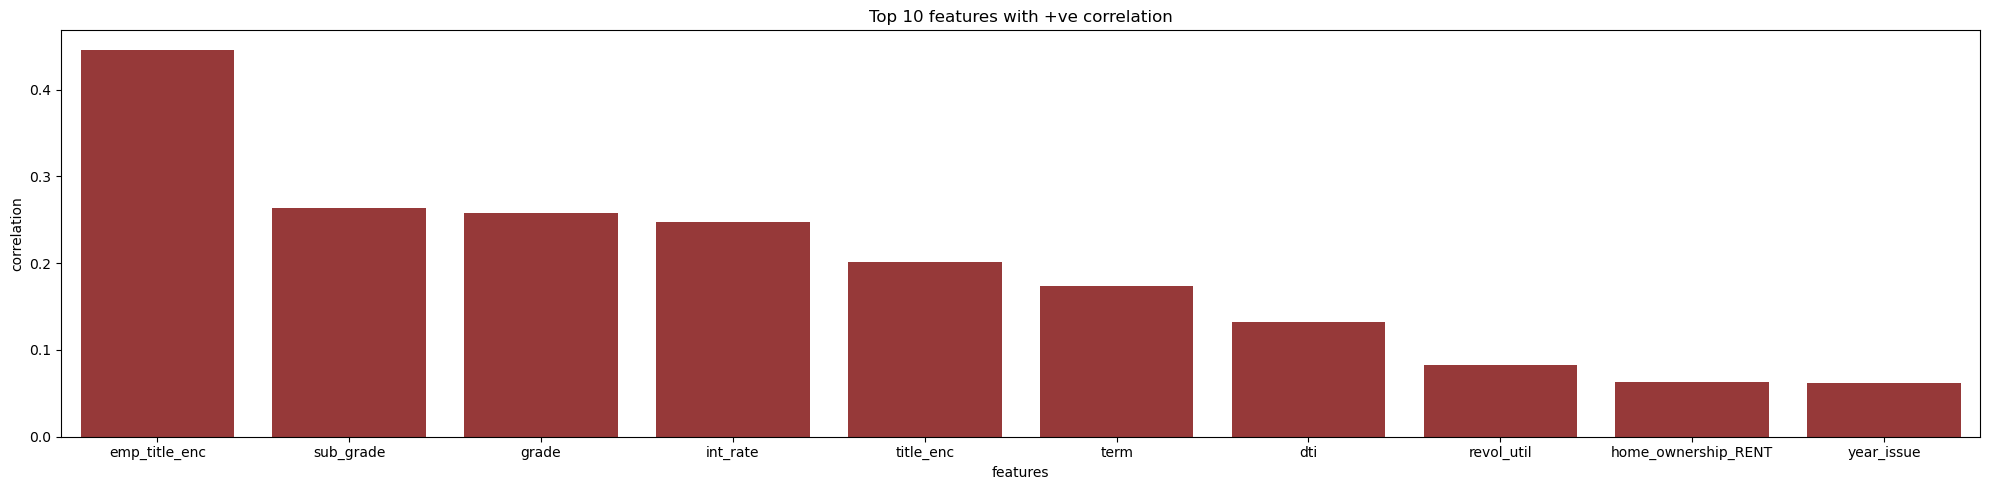

In [152]:
plt.figure(figsize=(20,5))
sns.barplot(x=top_features.index[1:11], y=top_features.values[1:11],color='brown')

plt.xlabel('features')
plt.ylabel('correlation')
plt.title('Top 10 features with +ve correlation')
plt.tight_layout()
plt.show()

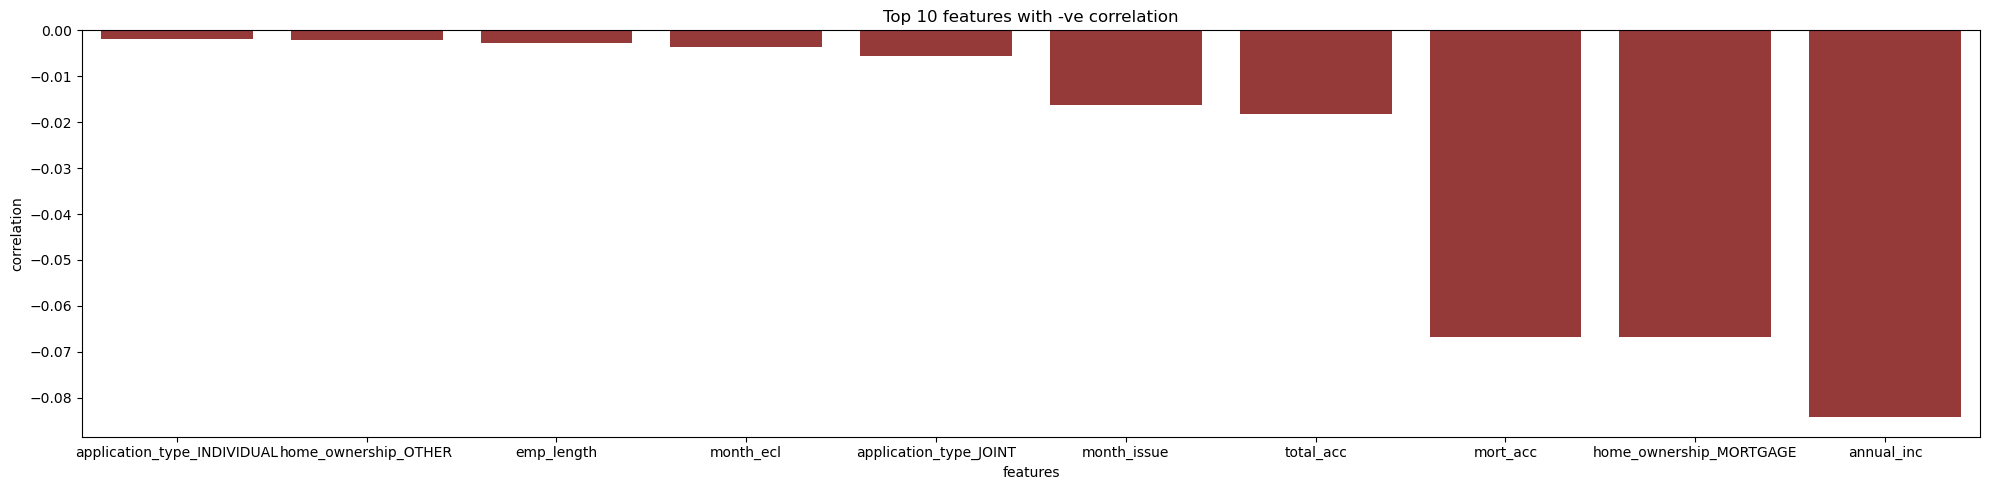

In [153]:
plt.figure(figsize=(20,5))
sns.barplot(x=top_features.index[-10::1], y=top_features.values[-10::1],color='brown')

plt.xlabel('features')
plt.ylabel('correlation')
plt.title('Top 10 features with -ve correlation')
plt.tight_layout()
plt.show()

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">
    
**Checking for Multicollinearity**

In [86]:
y = df["loan_status_enc"]
# Features (input variables)
X = df.drop("loan_status_enc",axis=1)

In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split

# splitting the data into traing and testing datasets before applying VIF
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [88]:
print("Training data:", X_train.shape) # this excludes target y_train
print("Testing data:", X_test.shape) # this excludes target y_test

Training data: (314764, 33)
Testing data: (78692, 33)


In [89]:
# Checking VIF of independent variables
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_sm.values, i)
                   for i in range(X_train_sm.shape[1])]
# converting into normal decimals from from scientific notation
vif_data['VIF'] = vif_data['VIF'].apply(lambda x: '{:.2f}'.format(x))

In [90]:
vif_data

,feature,VIF
0,const,3447240.04
1,loan_amnt,503.74
2,term,29.35
3,int_rate,29.61
4,installment,449.89
5,grade,22.54
6,sub_grade,45.06
7,emp_length,1.12
8,annual_inc,1.80
9,dti,1.46


<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

**Dropping columns with high VIF**

In [91]:
# creating a helper function to remove columns with VIF>threshold
def drop_high_vif(X, threshold=10):
    
    has_const = 'const' in X.columns
    cols = [c for c in X.columns if c != 'const']

    while True:
        # Calculate VIF for each column
        vif_list = [variance_inflation_factor(X[cols].values, i) for i in range(len(cols))]
        vif_df = pd.Series(vif_list, index=cols)
        
        # Get the highest VIF value
        max_vif = vif_df.max()
        
        if max_vif > threshold:
            drop_col = vif_df.idxmax()
            print(f"Dropping '{drop_col}' with VIF: {max_vif:.2f}")
            cols.remove(drop_col)   
        else:
            break
            
    # Putting the constant back at the end
    final_cols = (['const'] if has_const else []) + cols
    return X[final_cols]

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">
    
>taking sample of X_train for VIF checks because calculating VIF on over 300,000 rows is computationally expensive and slow because the algorithm runs a regression for every single feature you have.

In [92]:
X_sample = X_train_sm.sample(n=20000, random_state=42)

# 2. Run the VIF function on the sample
# This returns the final list of columns to keep
X_train_sampled_final = drop_high_vif(X_sample)

# 3. Apply those final columns to your FULL train and test sets
final_columns = X_train_sampled_final.columns
X_train_final = X_train_sm[final_columns] 
X_test_final = X_test_sm[final_columns]

Dropping 'home_ownership_MORTGAGE' with VIF: 1661337.70
Dropping 'year_issue' with VIF: 110181.81
Dropping 'loan_amnt' with VIF: 92180.41
Dropping 'year_ecl' with VIF: 2743.53
Dropping 'annual_inc' with VIF: 629.24
Dropping 'application_type_INDIVIDUAL' with VIF: 251.83
Dropping 'int_rate' with VIF: 190.19
Dropping 'revol_bal' with VIF: 96.75
Dropping 'sub_grade' with VIF: 88.13
Dropping 'purpose_enc' with VIF: 68.87
Dropping 'installment' with VIF: 51.94
Dropping 'title_enc' with VIF: 22.46
Dropping 'term' with VIF: 17.45
Dropping 'total_acc' with VIF: 13.39
Dropping 'emp_title_enc' with VIF: 10.90


<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">
    
**Key Observations**

> Sample of 20000 datapoints from training set were used for performing VIF checks.

> Threshold =10, any column with VIF > 10 are removed because such columns posses high multicollinarity, introduces redundancy and unnecessarily increases model complexity

In [93]:
X_train_final.shape,X_test_final.shape

((314764, 19), (78692, 19))

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

**Feature Scaling**

In [94]:
from sklearn.preprocessing import StandardScaler

#creating a list for columns from X_train with 'const' column removed
cols_to_scale = [c for c in X_train_final.columns if c != 'const']
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final[cols_to_scale]), 
                              columns=cols_to_scale, 
                              index=X_train_final.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test_final[cols_to_scale]), 
                             columns=cols_to_scale, 
                             index=X_test_final.index)

# 3. Add the constant BACK to the scaled data
X_train_scaled = sm.add_constant(X_train_scaled)
X_test_scaled = sm.add_constant(X_test_scaled)


In [95]:
X_train_scaled.head()

,const,grade,emp_length,dti,open_acc,pub_rec,revol_util,mort_acc,pub_rec_bankruptcies,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,initial_list_status_w,application_type_JOINT,month_issue,month_ecl
48458,1.0,-0.613513,1.059080,0.315913,1.363177,-0.331880,0.051378,-0.364329,-0.340721,-0.008912,-0.016628,-0.324093,-0.822891,-0.704382,1.354781,1.230867,-0.030367,0.126127,0.361868
41475,1.0,2.389394,-0.306918,0.340561,-0.256995,1.541475,-1.186960,0.647285,2.477780,-0.008912,-0.016628,-0.324093,-0.822891,-0.704382,1.354781,1.230867,-0.030367,0.418219,0.653103
79241,1.0,0.137214,0.512681,1.850229,0.148048,-0.331880,0.924775,0.647285,-0.340721,-0.008912,-0.016628,-0.324093,-0.822891,-0.704382,-0.738127,-0.812435,-0.030367,0.126127,-1.385541
221712,1.0,-0.613513,-0.853317,-0.954673,-0.459516,-0.331880,0.596739,-0.364329,-0.340721,-0.008912,-0.016628,-0.324093,-0.822891,1.419683,-0.738127,1.230867,-0.030367,0.418219,0.653103
307655,1.0,1.638667,-1.399715,-0.109259,3.185870,-0.331880,-1.802028,-0.870136,-0.340721,-0.008912,-0.016628,-0.324093,1.215228,-0.704382,1.354781,-0.812435,-0.030367,-1.626426,0.653103


In [96]:
X_test_scaled.head()

,const,grade,emp_length,dti,open_acc,pub_rec,revol_util,mort_acc,pub_rec_bankruptcies,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,initial_list_status_w,application_type_JOINT,month_issue,month_ecl
53694,1.0,-1.364239,-1.399715,0.137218,-1.067081,-0.331880,-1.141855,-0.870136,-0.340721,-0.008912,-0.016628,-0.324093,-0.822891,-0.704382,-0.738127,-0.812435,-0.030367,1.294496,-1.385541
4271,1.0,0.137214,-0.853317,0.398483,0.148048,1.541475,-1.699517,-0.870136,-0.340721,-0.008912,-0.016628,-0.324093,1.215228,1.419683,-0.738127,-0.812435,-0.030367,-0.750149,-0.220601
332431,1.0,-0.613513,1.059080,-1.512942,-0.662038,-0.331880,-1.182859,-0.870136,-0.340721,-0.008912,-0.016628,3.085537,-0.822891,1.419683,-0.738127,1.230867,-0.030367,-1.626426,0.944338
39265,1.0,-0.613513,-1.672915,1.884735,0.755612,-0.331880,-0.826120,-0.870136,-0.340721,-0.008912,-0.016628,-0.324093,1.215228,-0.704382,1.354781,1.230867,-0.030367,-1.626426,-1.094306
202341,1.0,-0.613513,-0.580117,0.722599,-1.067081,-0.331880,1.043689,-0.870136,-0.340721,-0.008912,-0.016628,-0.324093,1.215228,-0.704382,-0.738127,1.230867,-0.030367,-1.626426,1.235573


In [97]:
y_train.shape

(314764,)

In [98]:
combined = pd.concat([X_train_scaled, y_train], axis=1).dropna()

# 2. Re-separate them
y_final = combined['loan_status_enc'].astype(int)
X_final = combined.drop(columns=['loan_status_enc'])

# 3. Fit the model
model = sm.Logit(y_final, X_final).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.454531
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        loan_status_enc   No. Observations:               314764
Model:                          Logit   Df Residuals:                   314745
Method:                           MLE   Df Model:                           18
Date:                Fri, 08 May 2026   Pseudo R-squ.:                 0.07948
Time:                        02:38:47   Log-Likelihood:            -1.4307e+05
converged:                       True   LL-Null:                   -1.5542e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -1.5651      0.005 

In [99]:
model.params

const                                 -1.565136
grade                                  0.563472
emp_length                             0.010468
dti                                    0.224661
open_acc                               0.018683
pub_rec                                0.037048
revol_util                             0.047356
mort_acc                              -0.109073
pub_rec_bankruptcies                  -0.019078
home_ownership_NONE                    0.002683
home_ownership_OTHER                   0.001480
home_ownership_OWN                     0.040138
home_ownership_RENT                    0.108037
verification_status_Source Verified    0.112961
verification_status_Verified           0.079184
initial_list_status_w                  0.034709
application_type_JOINT                -0.038135
month_issue                           -0.037414
month_ecl                             -0.013600
dtype: float64

In [100]:
# dropping columns with high p_value (0.05)
X_final.drop(columns=['home_ownership_NONE','home_ownership_OTHER'],axis=1,inplace=True)
X_test_scaled.drop(columns=['home_ownership_NONE','home_ownership_OTHER'],axis=1,inplace=True)

In [118]:
from sklearn.linear_model import LogisticRegression

custom_weights = {0: 1, 1: 4} # more weightage to defaults

model = LogisticRegression(class_weight='balanced')
model.fit(X_final, y_train)

LogisticRegression(class_weight='balanced')

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

A quick sanity check on model performance

In [121]:
train_score = model.score(X_final, y_train)
test_score = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

Training Accuracy: 0.6543
Test Accuracy: 0.6499


<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

Since the training score and testing score are almost same, there is no issue of overfitting and training score of 0.7296 implies that model is moderatly good

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

Testing the model

In [122]:
y_pred = model.predict(X_test_scaled) # Standard 0.5 threshold

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">

**Model Evaluation Metrics**

>1. Confusion Matrix
>
>2. Classification Report
>
>3. AU-ROC Score
>
>4. AU-PR Score

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

Confusion Matrix & Classification Report

In [123]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[41228 21735]
 [ 5815  9914]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.65      0.75     62963
           1       0.31      0.63      0.42     15729

    accuracy                           0.65     78692
   macro avg       0.59      0.64      0.58     78692
weighted avg       0.76      0.65      0.68     78692



<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">

**Observations: confusion matrix**

<div style="font-family: 'Consolas'; color: #800000; font-size: 17px; line-height: 1.5;">

> True Negatives  : 41228 --> (actual = Fully Paid, predicted = Fully Paid)
>
> True Positives  : 9914 --> (actual = Charged Off, predicted = Charged Off)
>
> False Negatives : 5815 --> (actual = Charged Off, predicted = Fully Paid)
>
> False Positives : 21735 --> (actual = Fully Paid, predicted = Charged Off)

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">

**Observations: Classification Report**

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

>**Model Peformance : Identifying defaulters:**
    
>Recall - 0.63,  model is correctly identifying 63% of defaulters
>
>Precision - 0.31, the model is only 31% correct out all predictions flagged as "Charged Off'. This also means the model is flagging too many "good" people as "bad."
>
>F1 Score - 0.42, the model has a weak-to-moderate balance between catching defaults and being accurate about them
>
><div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">
>
>**Model Performance : Identifying 'good borrowers':**
>
>Recall - 0.65, model is correctly identifying 65% of good borrowers
>
>Precision - 0.88, model is 88% correct while identifying good borrowers
>
>F1 Score - 0.75, model has a better balance between identifying good borrowers and being accurate about them 

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

AU-ROC Score

In [131]:
from sklearn.metrics import roc_curve, roc_auc_score
y_probs = model.predict_proba(X_test_scaled)[:, 1] # for 
fpr, tpr, thr = roc_curve(y_test,y_probs) # y_probs = model.predict_proba(X_test_scaled)[:, 1], as we need only default cases -1

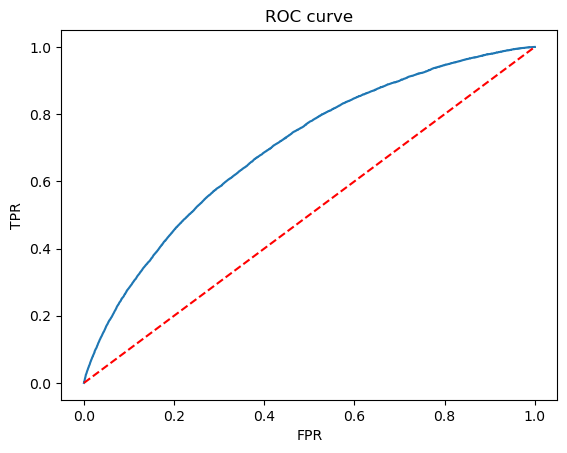

In [132]:
plt.plot(fpr,tpr)

#random model
plt.plot(fpr,fpr,'--',color='red' )
plt.title('ROC curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [133]:
j_scores = tpr - fpr

# 3. Find the index of the highest J-score
best_idx = np.argmax(j_scores)
best_threshold = thr[best_idx]

print(f"Optimal Threshold (Youden's J): {best_threshold:.4f}")
print(f"At this point - TPR: {tpr[best_idx]:.4f}, FPR: {fpr[best_idx]:.4f}")

Optimal Threshold (Youden's J): 0.4826
At this point - TPR: 0.6664, FPR: 0.3783


In [134]:
roc_auc_score(y_test,y_probs)

np.float64(0.6988208090431497)

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">
    
**Key Observations**
    
>AU-ROC curve measures how well the model rank positives(TPR) above negatives(FPR).  It shows the tug-of-war between catching "bad" borrowers (TPR) and wrongly rejecting "good" ones (FPR).

>**The Trade-off Point:** Looking at the curve where TPR is 0.8 (catching 80% of defaults), the corresponding FPR is roughly 0.5 which means to catch 80% of the defaults, we have to accept a 50% "false alarm" rate (rejecting half of your good customers).
  
>We require ROC AUC because it evaluates a model's performance across all possible decision thresholds, rather than just judging it on a single, arbitrary cutoff. However ROC AUC performs poor with imbalanced datasets like the one we have.

>ROC curves provide an aggregate measure of model performance across all possible classification thresholds. Hence it can make a poor model on the minority class (Charged Off) appear better by focusing more on the performance on the majority class (Fully Paid).

In [141]:
from sklearn.metrics import confusion_matrix, classification_report
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# This requires the model to be 70% sure before rejecting a loan

y_pred_strict = (y_probs > 0.48).astype(int)

print(f"--- Confusion Matrix (Threshold: {thr}) ---")
print(confusion_matrix(y_test, y_pred_strict))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_strict))
print()

--- Confusion Matrix (Threshold: [0.08265582 0.08988922 0.10954073 ... 0.93599524 0.93640858 0.93866744]) ---
[[38822 24141]
 [ 5177 10552]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.62      0.73     62963
           1       0.30      0.67      0.42     15729

    accuracy                           0.63     78692
   macro avg       0.59      0.64      0.57     78692
weighted avg       0.77      0.63      0.66     78692




<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

AU-PR Score - trade-off between being accurate (Precision) and being thorough (Recall).

In [142]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
precision, recall, thr = precision_recall_curve(y_test, y_probs)

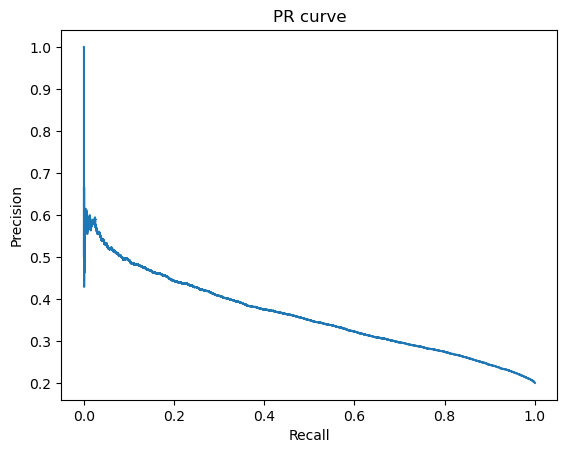

In [143]:
plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR curve')
plt.show()

In [144]:
auc(recall, precision)

np.float64(0.3595953623304471)

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">

**Key Observations**

>The "Area Under the Curve" (AUC-PR) is quite low here because the line is bowing toward the bottom-left.
>
>When the line bows toward the bottom-left, it means that as soon as we try to catch more defaults (Recall), your accuracy (Precision) drops very quickly.
>
>The model is struggling to find the "defaults" without accidentally grabbing a huge chunk of "good" borrowers at the same time.

<div style="font-family: 'Consolas'; color: #800000; font-size: 20px; line-height: 1.5;">

**Repayment Terms**

In [147]:
y_probs

array([0.22888039, 0.57397339, 0.35574451, ..., 0.32502908, 0.80193532,
       0.42739609])

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

**Creating risk buckets considering the balance between loosing interest (loosing good borrowers) and loosing principle(approving loans for bad borrowers)**

>1. Probability 0.0 - 0.3: "Green Zone." Auto-approve with lowest interest.(Low FP risk).
>
>2. Probability 0.3 - 0.6: "Yellow Zone."  offer a lower credit limit and high interest rate.
>
>3. Probability 0.6 - 1.0: "Red Zone." Reject. (High confidence of Default).

<div style="font-family: 'Consolas'; color: #800000; font-size: 18px; line-height: 1.5;">

**Insights and recomendations**

<div style="font-family: 'Consolas'; color: #800000; font-size: 16px; line-height: 1.5;">

> 1. Polynomial & Interaction Features : Logistic Regression assumes each variable acts alone. In the real world, Income and Debt (DTI) interact. A high debt is fine if income is huge, but deadly if income is low. Create new columns like Income * DTI and Income / Loan_Amount.
>
> 2. If a dataset is 80% "Safe" (0- Fully Paid) and 20% "Default" (1-Charged Off), a standard model is "lazy"—it guesses 0 for everyone to get an easy 80% accuracy. That creates massive False Negatives (missing the defaults). But in our case, massive False Positives (accusing the safe people)—means we’ve intentionally (or accidentally) told the model to "panic." When we used class_weight='balanced', we told the model: "Missing a single default is 4 times worse than wrongly accusing a good borrower." we can try for different weights and thrsholds and check for any increase in tpr.


#### **Trade-off Questions**


#### 1. **How can we make sure that our model can detect real defaulters and there are less false positives?**
##### Balancing the detection of real defaulters (Recall) while minimizing wrongly rejected good customers (False Positives) is the core challenge of credit risk modeling. Using Precision-Recall Curve we can visualize the trade-off and pick a specific threshold that maximizes the F1-score.
>
#### 2. **Since NPA (non-performing asset) is a real problem in this industry, it’s important we play safe and shouldn’t disburse loans to anyone. ?**
##### Instead of a Yes/No decision, use the y_probs to create a Safety Buffe. Instead of rejecting, we can Offer a collateral-backed loan or a much smaller credit limit.This way, even if they default (become an NPA), the "Asset" part of the Non-Performing Asset is protected by collateral.

### **Questionnaire**

#### 1. What percentage of customers have fully paid their Loan Amount?  
#### Ans - 80.38%

#### 2. Comment about the correlation between Loan Amount and Installment features
#### Ans- Both this features has a correlation coefficient of 0.97 which means highly positively correlated.

#### 3.	The majority of people have home ownership as **Joint**

#### 4.	People with grades ‘A’ are more likely to fully pay their loan. (T/F) - **False**

#### 5. Name the top 2 afforded job titles - **Teacher, Manager**

#### 6.	Thinking from a bank's perspective, which metric should our primary focus be on **F1 Score**

#### 7.	How does the gap in precision and recall affect the bank?
#### Ans - In banking, the gap between precision and recall represents a trade-off between operational waste and financial risk. Because the cost of a "false negative" (a defaulted loan) is typically much higher than a "false positive" (a rejected good applicant), banks often have to choose which "gap" to live with

#### 8.	Which were the features that heavily affected the outcome? - **grade, dti, mort_acc**

#### 9.	Will the results be affected by geographical location? (Yes/No) - **Yes**